#**0 | IMPORTS**

* **GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* **LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

#CONFIGURATION
pd.set_option('display.max_columns',None)
warnings.filterwarnings("ignore")

* **MACHINE LEARNING LIBRARIES**

In [ ]:
pip install shap

In [ ]:
#PACKAGES TO INSTALL

from sklearn.preprocessing import (OrdinalEncoder,
                                   StandardScaler,
                                   OneHotEncoder)

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

import shap

In [ ]:
#MODEL COMPETITION
from sklearn.model_selection import cross_val_score

#MODELS
from sklearn.linear_model import (LinearRegression,
                                  Ridge,
                                  Lasso,
                                  ElasticNet,
                                  SGDRegressor)

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import PolynomialFeatures

#MODEL OPTIMIZATION
from sklearn.model_selection import RandomizedSearchCV

#**1 | CHECK DATASET**

* **LOAD DATASET**

In [ ]:
df_file_route = ''

In [ ]:
df = pd.read_csv(df_file_route)

##**1.1 | SHAPE, HEAD, INFO, DESCRIBE**

The functions `.head()`, `.info()` & .`describe()` will help us get an initial general overview of the dataframe, as well as allow us to spot possible general errors in data types or records.

* **HEAD**

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


* **INFO**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

* **DESCRIBE**

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


* **SHAPPE**

In [ ]:
df.shape

(1460, 81)

#**2 | DATA CLEANING**

##**2.1 | DUPLICATED VALUES**

In [ ]:
df[df.duplicated(keep=False)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


* **DROP DUPLICATES**

There are no dupplicated values in the database.

##**2.2 | NULL VALUES**

###**2.2.0 | COLUMN CHECK & REFEREMCE METHODS**

* **COLUMN CHECK**

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


###**2.2.1 | COLUMN: ['id']** .drop()

In [ ]:
df.drop(['Id'],
        axis=1,
        inplace=True)

###**2.2.2 | COLUMN: ['Electrical']** - .mode()

In [ ]:
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)

###**2.2.3 | COLUMN: ['MiscFeature','PoolQC','Alley']** - bool

This column indicates the presence of other elements that are not listed in the previous columns. It was decided to group the set of values into a boolean column, with 1 if they have their own values and 0 if not.

In [ ]:
bool_col = ['MiscFeature','PoolQC','Alley']

for col in bool_col:
  df.loc[~df[col].isnull(), col] = 1
  df[col].fillna(0, inplace=True)

###**2.2.4 | COLUMNS BASEMENT: ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']**

The columns `[BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2]` refer to the basement of the houses. The vast majority of them share NaN values, likely referring to houses that do not have a basement.

* However, for the columns `BsmtExposure` and `BsmtFinType2` there is an additional NaN value, which will be analyzed beforehand.

In [ ]:
df[(~df['BsmtQual'].isna()) & ((df['BsmtExposure'].isna()) | (df['BsmtFinType2'].isna()))]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
332,20,RL,85.0,10655,Pave,0,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2003,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,296.0,Gd,TA,PConc,Gd,TA,No,GLQ,1124,NaN,479,1603,3206,GasA,Ex,Y,SBrkr,1629,0,0,1629,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2003.0,RFn,3,880,TA,TA,Y,0,0,0,0,0,0,0,NaN,0,0,10,2009,WD,Normal,284000
948,60,RL,65.0,14006,Pave,0,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,144.0,Gd,TA,PConc,Gd,TA,NaN,Unf,0,Unf,0,936,936,GasA,Ex,Y,SBrkr,936,840,0,1776,0,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,2002.0,RFn,2,474,TA,TA,Y,144,96,0,0,0,0,0,NaN,0,0,2,2006,WD,Normal,192500


In [ ]:
df.loc[(~df['BsmtQual'].isna()) & (df['BsmtExposure'].isna()), 'BsmtExposure'] = 'No'
df.loc[(~df['BsmtQual'].isna()) & (df['BsmtFinType2'].isna()), 'BsmtFinType2'] = 'Unf'

* The rest of the values may correspond to houses without a basement.

In [ ]:
basement_nulls = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']

for col in basement_nulls:
  df[col].fillna('None',inplace=True)

###**2.2.5 | COLUMNS GARAGE: ['GarageType','GarageFinish','GarageQual','GarageCond','GarageYrBlt']**

GarageYrBlt	81
A similar approach will be applied to the columns related to garages, with the exception of `GarageYrBlt`, which, being a numerical value, will be assigned -9999.

In [ ]:
garage_nulls = ['GarageType','GarageFinish','GarageQual','GarageCond','GarageYrBlt']

for col in garage_nulls:
    if df[col].dtype == 'O':
        df[col].fillna('None', inplace=True)
    else:
        df[col].fillna(-9999, inplace=True)

###**2.2.6 | COLUMN ['MasVnrType','MasVnrArea']**

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
LotFrontage,259
MasVnrType,872
MasVnrArea,8
FireplaceQu,690
Fence,1179


In [ ]:
df.loc[(df['MasVnrArea']==0) & df['MasVnrType'].isna(),'MasVnrType'] = 'None'

In [ ]:
df.loc[df['MasVnrArea'].isna(),'MasVnrType'] = 'None'
df.loc[df['MasVnrType']=='None','MasVnrArea'] = 0

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
LotFrontage,259
MasVnrType,5
FireplaceQu,690
Fence,1179


In [ ]:
df[df['MasVnrType'].isna()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
624,60,RL,80.0,10400,Pave,0,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,2Story,6,5,1972,1972,Gable,CompShg,VinylSd,VinylSd,NaN,288.0,TA,TA,CBlock,TA,TA,No,Rec,247,Unf,0,485,732,GasA,Gd,Y,SBrkr,1012,778,0,1790,1,0,1,2,4,1,TA,8,Min2,1,TA,Attchd,1972.0,RFn,2,484,TA,TA,Y,148,0,0,0,147,0,0,NaN,0,0,11,2006,WD,Normal,165150
773,20,RL,70.0,10150,Pave,0,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,5,1958,1958,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,1.0,TA,TA,CBlock,TA,TA,No,Rec,456,Unf,0,456,912,GasA,Ex,Y,FuseA,912,0,0,912,0,0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1958.0,RFn,1,275,TA,TA,Y,0,0,0,0,0,0,0,NaN,0,0,7,2007,COD,Normal,114500
1230,90,RL,NaN,18890,Pave,0,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,RRAe,Duplex,1.5Fin,5,5,1977,1977,Shed,CompShg,Plywood,Plywood,NaN,1.0,TA,TA,CBlock,Gd,TA,No,GLQ,498,Rec,211,652,1361,GasA,Ex,Y,SBrkr,1361,1259,0,2620,0,0,2,2,4,2,TA,12,Typ,1,TA,BuiltIn,1977.0,RFn,2,600,TA,TA,N,155,24,145,0,0,0,0,NaN,1,8300,8,2007,WD,Normal,190000
1300,60,RL,NaN,10762,Pave,0,IR1,Lvl,AllPub,CulDSac,Gtl,Gilbert,Norm,Norm,1Fam,2Story,7,5,1999,1999,Gable,CompShg,VinylSd,VinylSd,NaN,344.0,Gd,TA,PConc,Gd,TA,No,GLQ,694,Unf,0,284,978,GasA,Ex,Y,SBrkr,1005,978,0,1983,0,0,2,1,3,1,Gd,9,Typ,1,TA,Attchd,1999.0,Fin,2,490,TA,TA,Y,0,0,0,0,0,0,0,NaN,0,0,5,2009,WD,Normal,225000
1334,160,RM,24.0,2368,Pave,0,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,TwnhsE,2Story,5,6,1970,1970,Gable,CompShg,HdBoard,HdBoard,NaN,312.0,TA,TA,CBlock,TA,TA,No,LwQ,765,Unf,0,0,765,GasA,TA,Y,SBrkr,765,600,0,1365,0,0,1,1,3,1,TA,7,Min1,0,NaN,Attchd,1970.0,Unf,2,440,TA,TA,Y,0,36,0,0,0,0,0,NaN,0,0,5,2009,WD,Normal,125000


In [ ]:
df['MasVnrType'].fillna(df[df['MasVnrArea'] != 0]['MasVnrType'].mode().iloc[0],inplace=True)

###**2.2.6 | COLUMN ['FireplaceQu']**

In [ ]:
df.loc[(df['Fireplaces']==0) & (df['FireplaceQu'].isna()), 'FireplaceQu'] = 'None'

###**2.2.7 | COLUMN ['LotFrontage']**

In [ ]:
df[df['LotFrontage'].isna()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
7,60,RL,NaN,10382,Pave,0,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,0,NaN,1,350,11,2009,WD,Normal,200000
12,20,RL,NaN,12968,Pave,0,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,6,1962,1962,Hip,CompShg,HdBoard,Plywood,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,737,Unf,0,175,912,GasA,TA,Y,SBrkr,912,0,0,912,1,0,1,0,2,1,TA,4,Typ,0,None,Detchd,1962.0,Unf,1,352,TA,TA,Y,140,0,0,0,176,0,0,NaN,0,0,9,2008,WD,Normal,144000
14,20,RL,NaN,10920,Pave,0,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,MetalSd,MetalSd,BrkFace,212.0,TA,TA,CBlock,TA,TA,No,BLQ,733,Unf,0,520,1253,GasA,TA,Y,SBrkr,1253,0,0,1253,1,0,1,1,2,1,TA,5,Typ,1,Fa,Attchd,1960.0,RFn,1,352,TA,TA,Y,0,213,176,0,0,0,0,GdWo,0,0,5,2008,WD,Normal,157000
16,20,RL,NaN,11241,Pave,0,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,7,1970,1970,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,180.0,TA,TA,CBlock,TA,TA,No,ALQ,578,Unf,0,426,1004,GasA,Ex,Y,SBrkr,1004,0,0,1004,1,0,1,0,2,1,TA,5,Typ,1,TA,Attchd,1970.0,Fin,2,480,TA,TA,Y,0,0,0,0,0,0,0,NaN,1,700,3,2010,WD,Normal,149000
24,20,RL,NaN,8246,Pave,0,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,8,1968,2001,Gable,CompShg,Plywood,Plywood,None,0.0,TA,Gd,CBlock,TA,TA,Mn,Rec,188,ALQ,668,204,1060,GasA,Ex,Y,SBrkr,1060,0,0,1060,1,0,1,0,3,1,Gd,6,Typ,1,TA,Attchd,1968.0,Unf,1,270,TA,TA,Y,406,90,0,0,0,0,0,MnPrv,0,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,20,RL,NaN,12546,Pave,0,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,7,1981,1981,Gable,CompShg,MetalSd,MetalSd,BrkFace,310.0,Gd,Gd,CBlock,Gd,TA,No,BLQ,678,Unf,0,762,1440,GasA,Ex,Y,SBrkr,1440,0,0,1440,0,0,2,0,3,1,Gd,7,Typ,1,TA,Attchd,1981.0,Fin,2,467,TA,TA,Y,0,0,99,0,0,0,0,NaN,0,0,4,2007,WD,Normal,182900
1431,120,RL,NaN,4928,Pave,0,IR1,Lvl,AllPub,Inside,Gtl,NPkVill,Norm,Norm,TwnhsE,1Story,6,6,1976,1976,Gable,CompShg,Plywood,Plywood,None,0.0,TA,TA,CBlock,Gd,TA,No,LwQ,958,Unf,0,0,958,GasA,TA,Y,SBrkr,958,0,0,958,0,0,2,0,2,1,TA,5,Typ,0,None,Attchd,1976.0,RFn,2,440,TA,TA,Y,0,60,0,0,0,0,0,NaN,0,0,10,2009,WD,Normal,143750
1441,120,RM,NaN,4426,Pave,0,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,TwnhsE,1Story,6,5,2004,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,147.0,Gd,TA,PConc,Gd,TA,Av,GLQ,697,Unf,0,151,848,GasA,Ex,Y,SBrkr,848,0,0,848,1,0,1,0,1,1,Gd,3,Typ,1,TA,Attchd,2004.0,RFn,2,420,TA,TA,Y,149,0,0,0,0,0,0,NaN,0,0,5,2008,WD,Normal,149300
1443,30,RL,NaN,8854,Pave,0,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Unf,6,6,1916,1950,Gable,CompShg,Wd Sdng,Wd Sdng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,Grav,Fa,N,FuseF,952,0,0,952,0,0,1,0,2,1,Fa,4,Typ,1,Gd,Detchd,1916.0,Unf,1,192,Fa,Po,P,

In [ ]:
#FIRST ROUND
relevant_col = ['LotShape', 'LotConfig', 'LandContour','MSZoning', 'BldgType', 'HouseStyle','GarageType']

type_modes = df.groupby(relevant_col)['LotFrontage'].transform(lambda x: x.mean())
df['LotFrontage'].fillna(type_modes, inplace=True)

In [ ]:
#SECOND ROUND
relevant_col2 = ['LotConfig', 'HouseStyle', 'BldgType', 'GarageType']

type_modes2 = df.groupby(relevant_col2)['LotFrontage'].transform(lambda x: x.mean())
df['LotFrontage'].fillna(type_modes2, inplace=True)

In [ ]:
#THIRD ROUND
df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace=True)

##**2.3 | OUTLIERS**

###**2.3.1 | CHECK NUMERIC `.describe()`**

Tras un analisis de las columnas numéricas (`int`, `float` & `bool`), se puede visualizar que no existen en principio valores atípicos en el dataset.

In [ ]:
df.describe()

,MSSubClass,LotFrontage,LotArea,Alley,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscFeature,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.644572,10516.828082,0.062329,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1314.000685,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,0.004795,0.036986,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,23.221266,9981.264932,0.241835,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,2742.859678,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,0.069100,0.188793,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,0.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,-9999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7553.500000,0.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1958.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,70.000000,9478.500000,0.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1977.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,0.000000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,1.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,1.000000,1.000000,15500.000000,12.000000,2010.000000,755000.000000


###**2.3.2 | CORRECT VALUES NUMERIC**

* **KITCHEN**

Un único registro aparece sin cocina, lo cual resulta muy extraño al tratarse de un dataset de casas e indicar además que su `KitchenQual` es Average ('`TA`'). Se asume que se trata de un valor outlier y se modificará a 1

In [ ]:
df[df['KitchenAbvGr']==0]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
954,90,RL,35.0,9400,Pave,0,IR1,Lvl,AllPub,CulDSac,Gtl,Edwards,Norm,Norm,Duplex,SFoyer,6,5,1975,1975,Flat,Tar&Grv,WdShing,Plywood,BrkFace,250.0,TA,TA,CBlock,Gd,Gd,Gd,GLQ,945,Unf,0,0,945,GasA,TA,Y,SBrkr,980,0,0,980,0,2,2,0,4,0,TA,4,Typ,0,None,None,-9999.0,None,0,0,None,None,Y,0,0,0,0,0,0,0,NaN,0,0,10,2006,WD,AdjLand,127500


In [ ]:
df.loc[df['KitchenAbvGr']==0, 'KitchenAbvGr'] = 1

* **BASEMENT SIZE** - NO OUTLIER

En principio parecía un outlier, pero va en concordancia con otros valores de tamaño.

In [ ]:
df[df['TotalBsmtSF']>6000]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,60,RL,313.0,63887,Pave,0,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,1,NaN,0,0,1,2008,New,Partial,160000


* **YEAR BUILD vs YEAR REMODELATED** - NO OUTLIER

In [ ]:
df[(df['YearRemodAdd']) < (df['YearBuilt'])]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


###**2.3.3 | CHECK CATEGORIC**

In [ ]:
for i in df:
  if df[i].dtype.kind == 'O':
    print(i, df[i].value_counts(), '\n')

MSZoning MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64 

Street Street
Pave    1454
Grvl       6
Name: count, dtype: int64 

LotShape LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 

LandContour LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64 

Utilities Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64 

LotConfig LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64 

LandSlope LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64 

Neighborhood Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17


###**2.3.4 | CORRECT VALUES CATEGORIC**

* **COLUMN DROP ['Utilities','Condition2']]**

Se trata de variables muy desbalanceadas, lo cual aporta muy poca información predictiva al modelo.

In [ ]:
var_to_drop = ['Utilities','Condition2']

In [ ]:
var_to_drop = ['Utilities','Condition2']
df.drop(columns=var_to_drop, inplace=True)

* **COLUMN VALUES MERGE**

In [ ]:
#LotShape
df['LotShape'] = df['LotShape'].replace({'IR2': 'IR2_3', 'IR3': 'IR2_3'})

#LotConfig
df['LotConfig'] = df['LotConfig'].replace({'FR2': 'FR2_3', 'FR3': 'FR2_3'})

#SaleType
df['Condition1'] = df['Condition1'].replace({
    'RRAn': 'RRA',
    'RRAe': 'RRA',
    'RRNn': 'RRN',
    'RRNe': 'RRN',
    'PosN': 'Pos',
    'PosA': 'Pos'
})

#SaleType
df['SaleType'] = df['SaleType'].replace({
    'ConLD': 'Con',
    'ConLI': 'Con',
    'ConLw': 'Con',
    'CWD': 'WD',
})

#Functional
df['Functional'] = df['Functional'].replace({
    'Min2': 'Min',
    'Min1': 'Min',
    'Maj1': 'Maj',
    'Maj2': 'Maj',
    'Sev' : 'Maj',
})

#Electrical
df['Electrical'] = df['Electrical'].replace({
    'FuseA': 'Fuse',
    'FuseF': 'Fuse',
    'FuseP': 'Fuse',
    'Mix': 'Fuse'})

#HeatingQC
df['HeatingQC'] = df['HeatingQC'].replace({
    'Ex': 'Excelent',
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#GarageQual
df['GarageQual'] = df['GarageQual'].replace({
    'Ex': 'Good',
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#GarageCond
df['GarageCond'] = df['GarageCond'].replace({
    'Ex': 'Good',
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#BsmtQual
df['BsmtQual'] = df['BsmtQual'].replace({
    'Ex': 'Excelent',
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#BsmtCond
df['BsmtCond'] = df['BsmtCond'].replace({
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#ExterQual
df['ExterQual'] = df['ExterQual'].replace({
    'Ex': 'Excelent',
    'Gd': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#ExterCond
df['ExterCond'] = df['ExterCond'].replace({
    'Gd': 'Good',
    'Ex': 'Good',
    'TA': 'Average',
    'Fa': 'Low',
    'Po': 'Low'})

#Exterior1st & Exterior2nd
corr_map = {
    'Wd Sdng': 'Wood',
    'Wd Shng': 'Wood',
    'WdShing': 'Wood',
    'HdBoard': 'HardBoard',
    'CemntBd': 'CementBoard',
    'CmentBd': 'CementBoard',
    'BrkComm': 'Brick',
    'Brk Cmn': 'Brick',
    'BrkFace': 'Brick',
    'AsbShng': 'Asbestos',
    'AsphShn': 'CementBoard',
    'ImStucc': 'Stucco',
    'CBlock': 'CementBoard',
    'Other': 'Other',
    'Stone': 'Brick',
}

df['Exterior1st'] = df['Exterior1st'].replace(corr_map)
df['Exterior2nd'] = df['Exterior2nd'].replace(corr_map)


#HouseStyle
df['HouseStyle'] = df['HouseStyle'].replace({
    '1.5Fin': '1.5',
    '1.5Unf': '1.5',
    '2.5Fin': '2.5',
    '2.5Unf': '2.5',
    'SLvl': 'Split',
    'SFoyer': 'Split'
    })

#RoofMatl
df['RoofMatl'] = df['RoofMatl'].apply(lambda x: 'CompShg' if x == 'CompShg' else 'Other')

#Exterior2nd
df['Exterior2nd'] = df['Exterior2nd'].replace({'Other': 'VinylSd'})

#Foundation
df['Foundation'] = df['Foundation'].replace({'Stone': 'Other','Wood': 'Other'})

#Heating
df['Heating'] = df['Heating'].replace({
    'GasA': 'Gas',
    'GasW': 'Gas',
    'Grav': 'No Gas',
    'Wall': 'No Gas',
    'Floor': 'No Gas',
    'OthW': 'No Gas'
    })

#RoofStyle
df['RoofStyle'] = df['RoofStyle'].replace({
    'Gambrel': 'Other',
    'Mansard': 'Other',
    'Flat': 'Other',
    'Shed': 'Other'
})

#SaleCondition
df['SaleCondition'] = df['SaleCondition'].replace({
    'Family': 'Other',
    'Alloca': 'Other',
    'AdjLand': 'Other'
})

#GarageType
df['GarageType'] = df['GarageType'].replace({
    'Basment': 'Other',
    'CarPort': 'Other',
    '2Types': 'Other'
})

In [ ]:
#Neighborhood
def eighborhood_classifier (n):
  if n in ['MeadowV','IDOTRR','BrDale']:
    return 'F'

  elif n in ['BrkSide','Edwards','OldTown']:
    return 'E'

  elif n in ['Mitchel','NAmes','NPkVill','SWISU','Blueste','Sawyer']:
    return 'D'

  elif n in ['SawyerW','NWAmes','Gilbert','Blmngtn','CollgCr']:
    return 'C'

  elif n in ['Crawfor','ClearCr','Somerst','Veenker','Timber']:
    return 'B'

  else:
    return 'A'

df['Neighborhood'] = df['Neighborhood'].apply(eighborhood_classifier)

## **2.4 | CORRECT DATATYPES**

Finally, it is important to verify that the data stored in each variable is consistent with its type.

The most common case is **numeric values** stored as strings. In this case, all the data is properly configured.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          1460 non-null   int64  
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyl

#**3 | FEATURE ENGINEERING**

##**3.1 | CATEGORIC & NUMERIC VARIABLES TO BOOL**

Given the imbalance present in some variables—categorical and especially numerical—this can generate excessive noise in certain variables. Since these affect the price, the best option considered was to convert them to `bool`.

###**3.1.1 | CATEGORIC**

In [ ]:
df['StreetPaved'] = (df['Street'] == 'Pave').astype(int)
df.drop(columns='Street',inplace=True)

In [ ]:
df['HeatingGas'] = (df['Heating'] == 'Gas').astype(int)
df.drop(columns='Heating',inplace=True)

In [ ]:
df['CentralAir'] = (df['CentralAir'] == 'Y').astype(int)

In [ ]:
df['ElectricalStandard'] = (df['Electrical'] == 'SBrkr').astype(int)
df.drop(columns='Electrical',inplace=True)

In [ ]:
df['RoofMatShingles'] = (df['RoofMatl'] == 'CompShg').astype(int)
df.drop(columns='RoofMatl',inplace=True)

###**3.1.2 | NUMERIC**

Due to the imbalance in some variables, which contribute significant differences in price, it was decided to also convert them to boolean, as their data is sometimes inconsistent because of the low number of records.

In [ ]:
to_boolean = ['LowQualFinSF','BsmtHalfBath','3SsnPorch','PoolArea','MiscVal']

for col in to_boolean:
    df[col] = df[col] > 0

###**3.1.3 | CORRECT DATA TYPES - TO BOOL**

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int', 'float'] and len(df[col].unique()) == 2:
      df[col]=df[col].astype('bool')

#**4 | UNIVARIABLE ANALYSIS**

##**4.1 | NUMERIC VISUALIZATION**

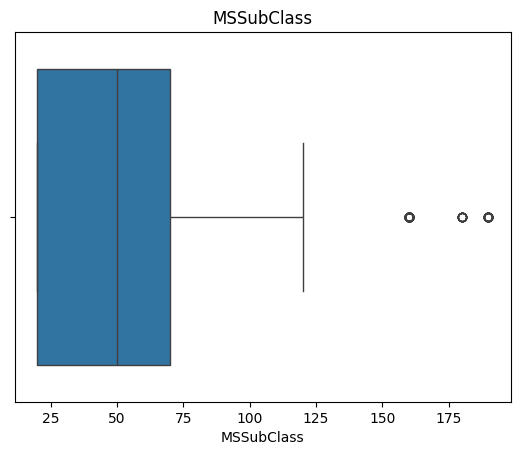

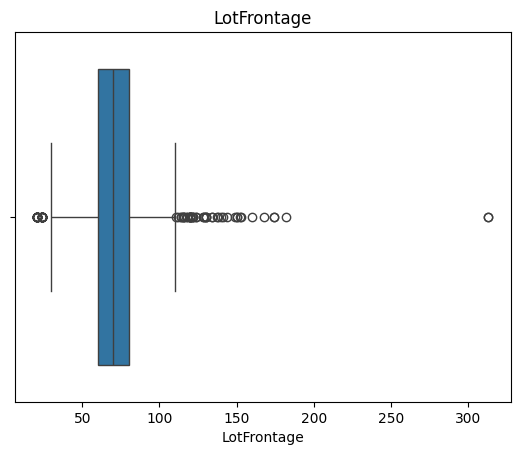

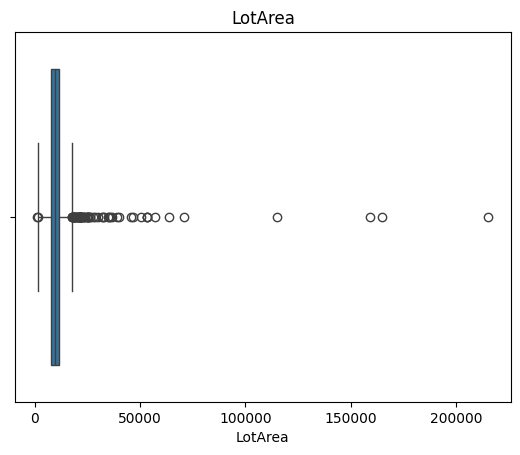

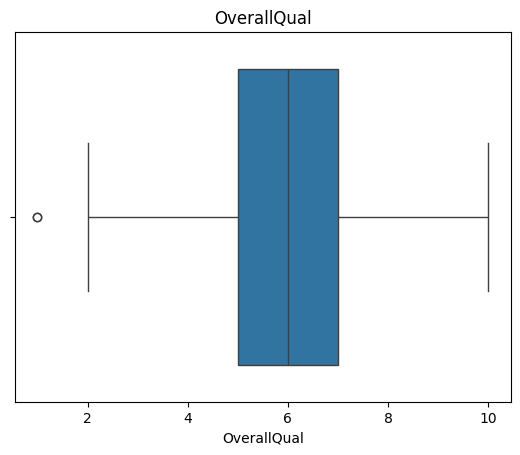

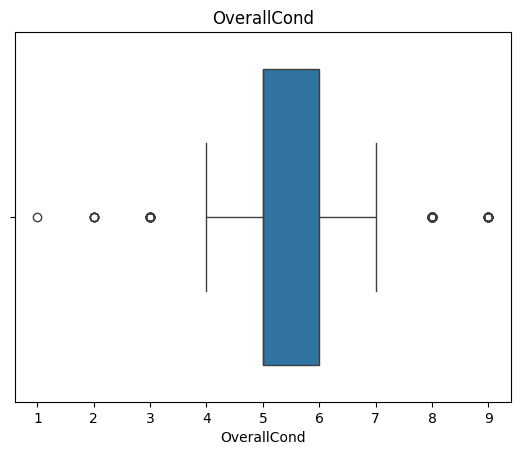

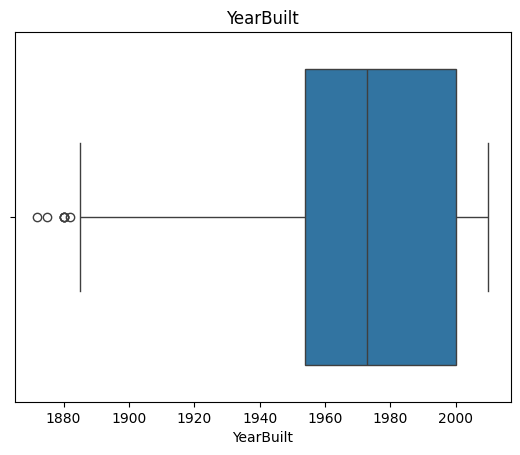

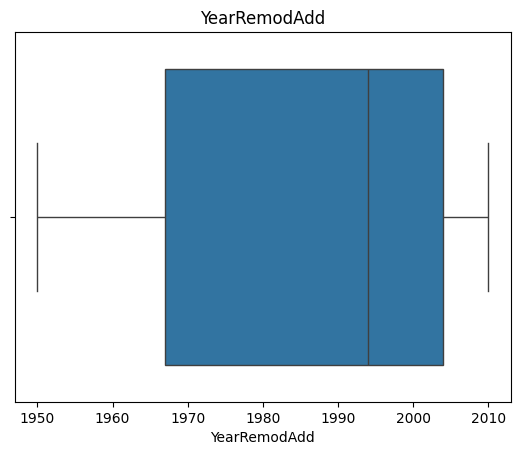

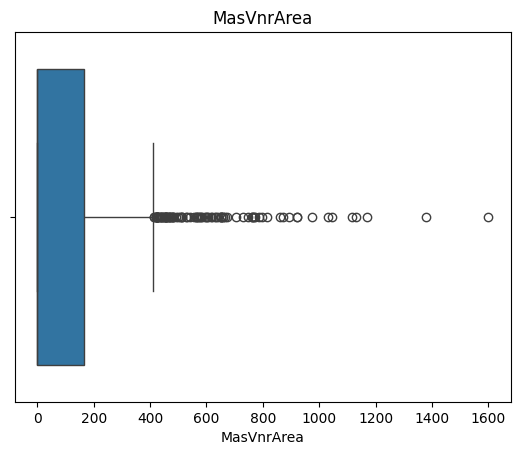

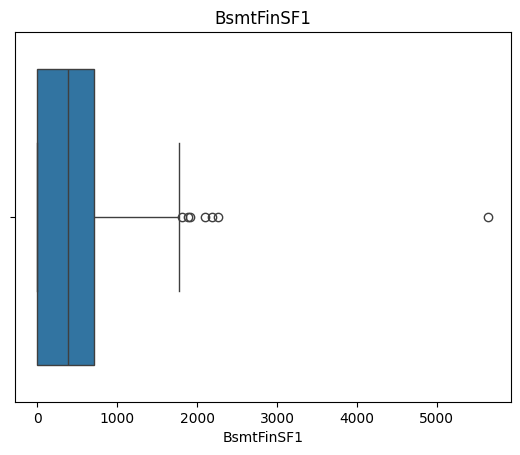

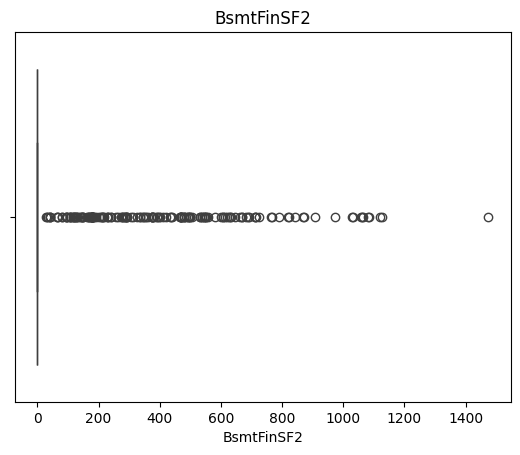

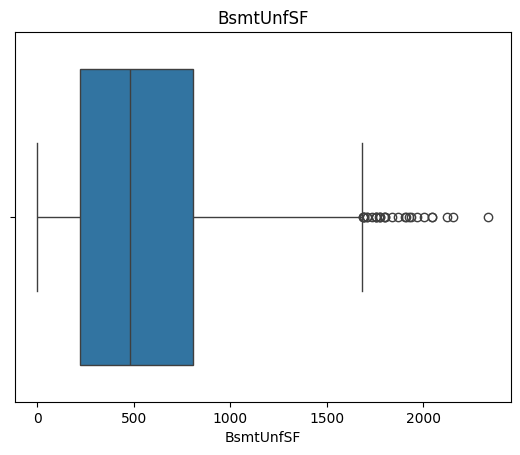

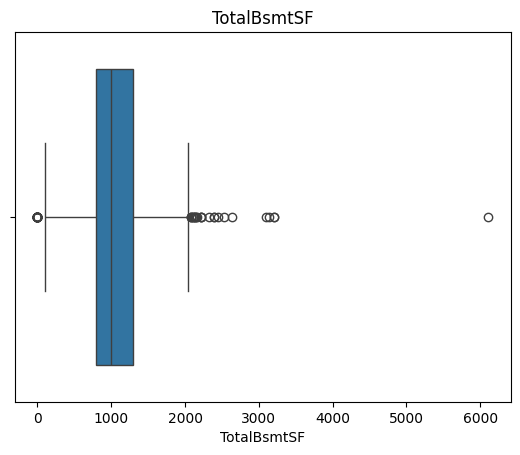

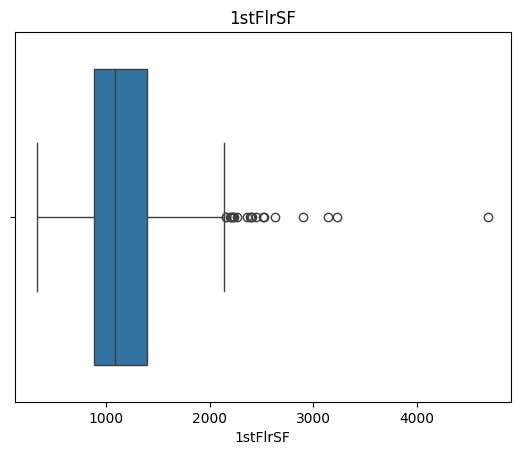

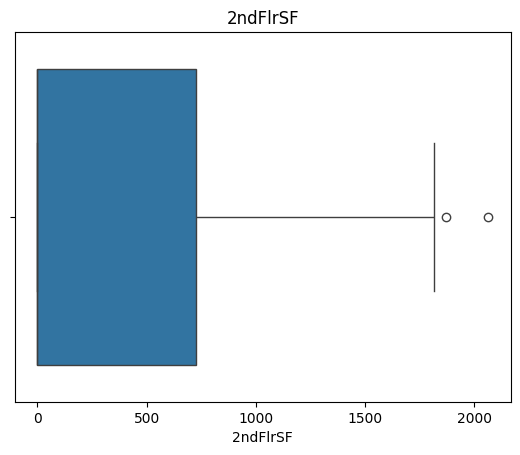

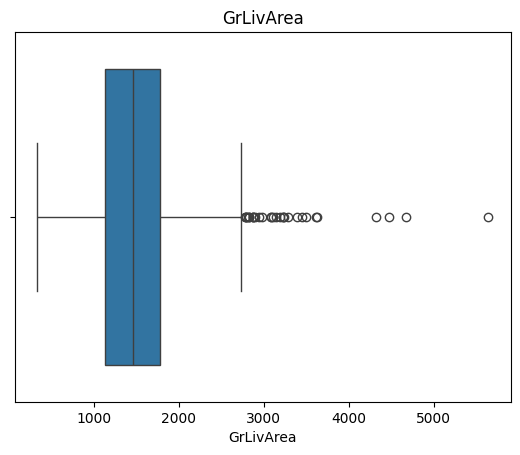

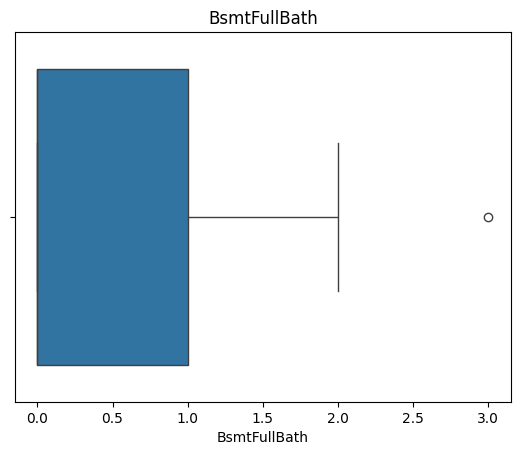

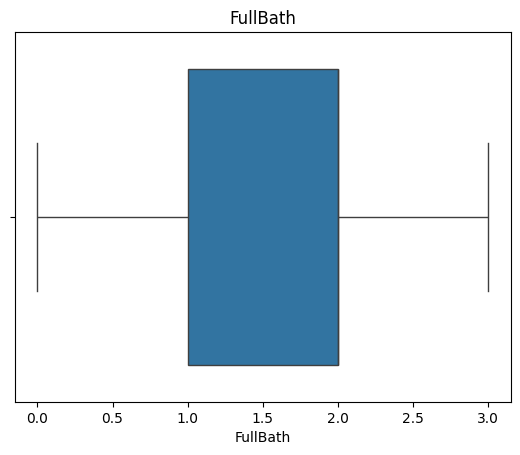

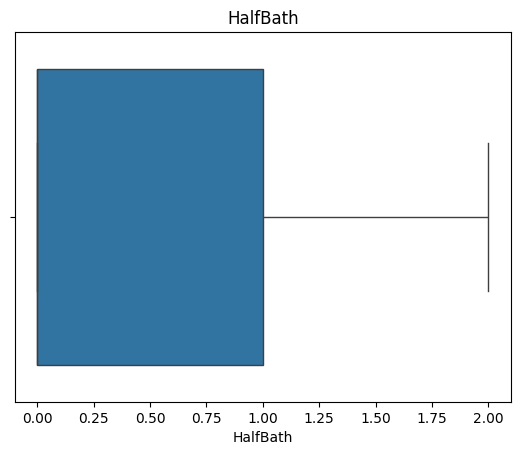

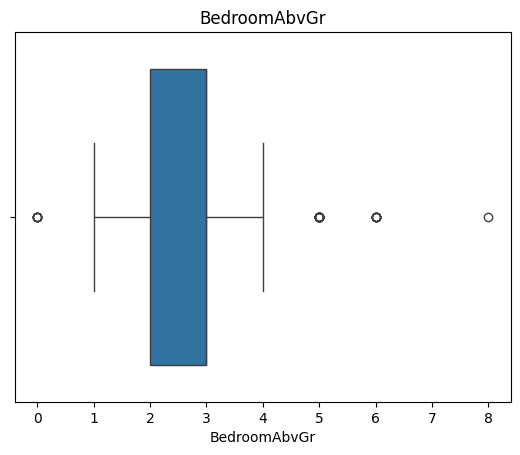

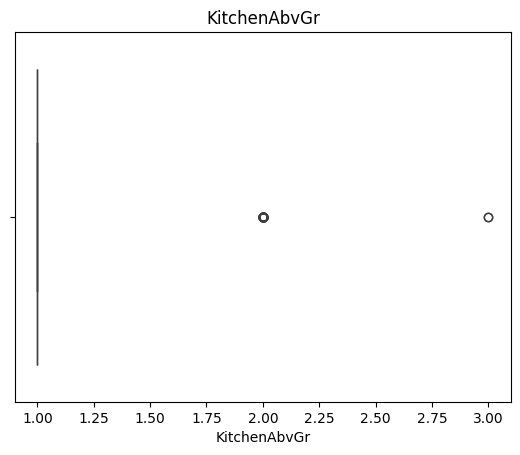

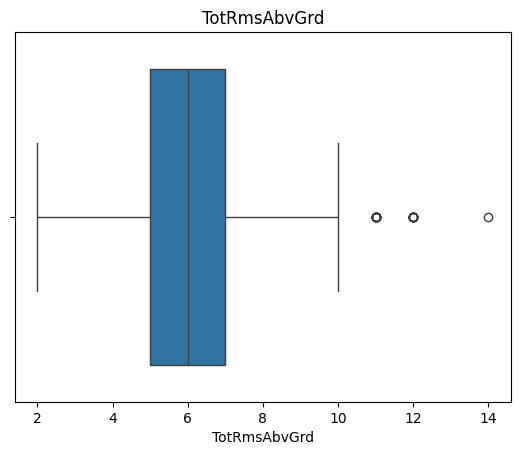

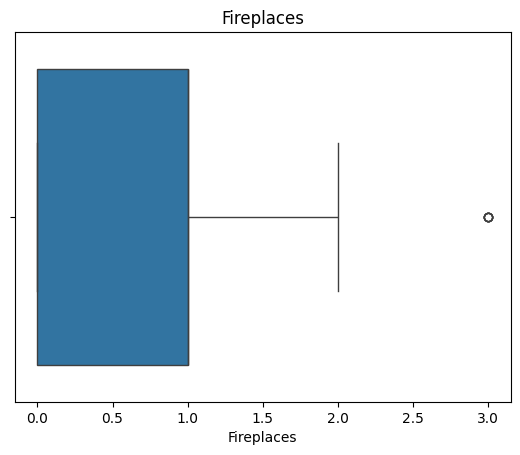

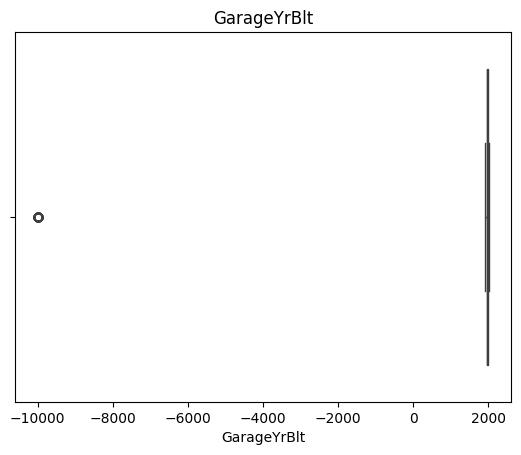

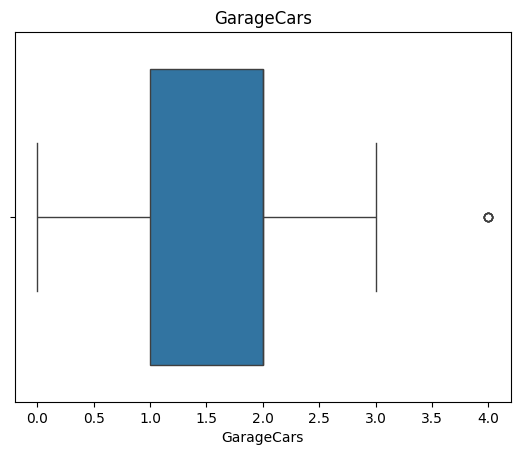

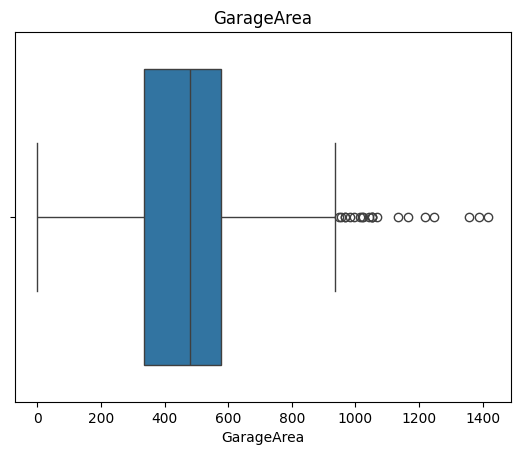

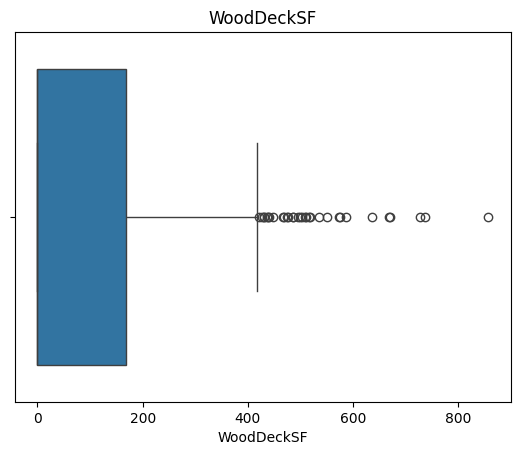

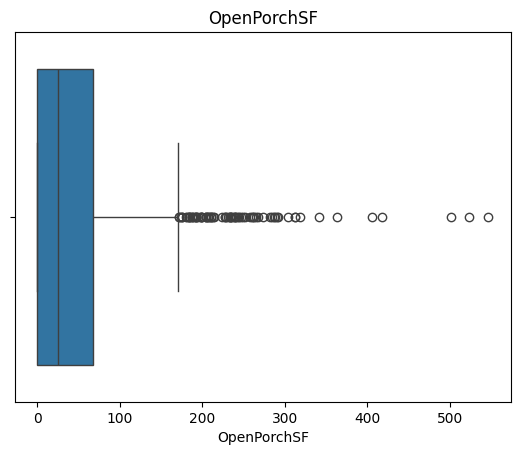

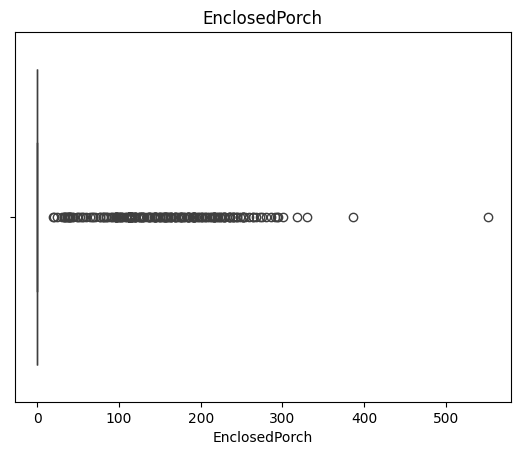

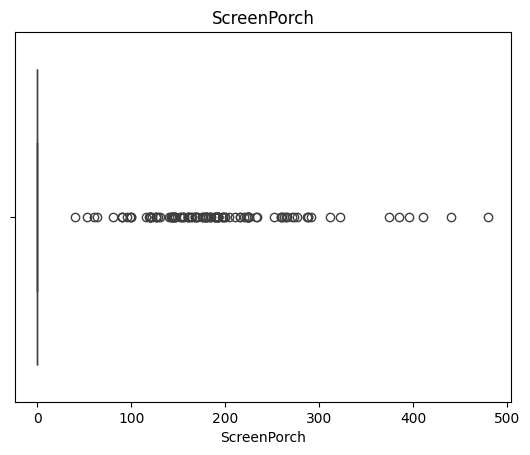

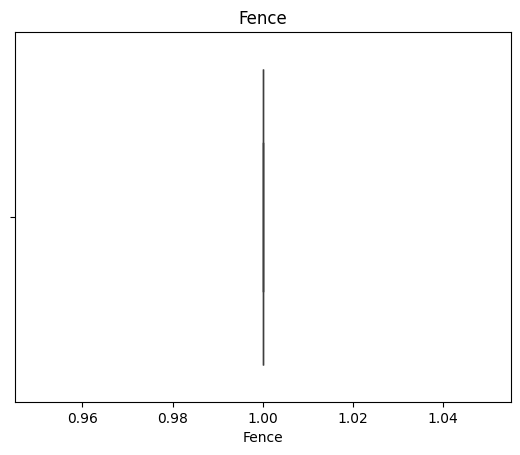

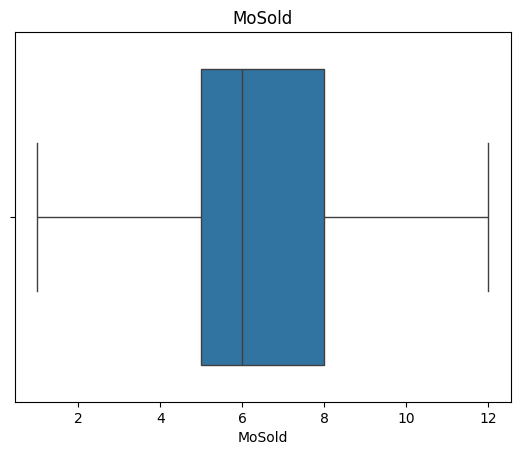

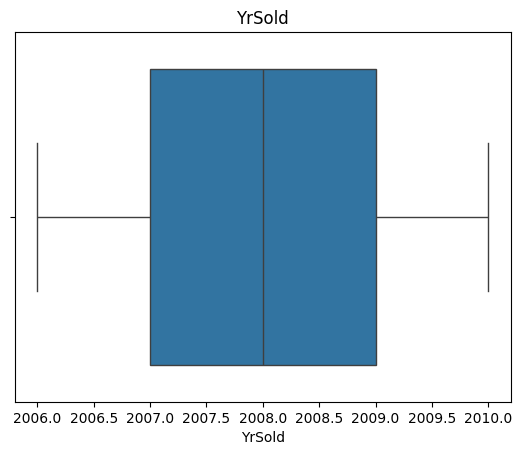

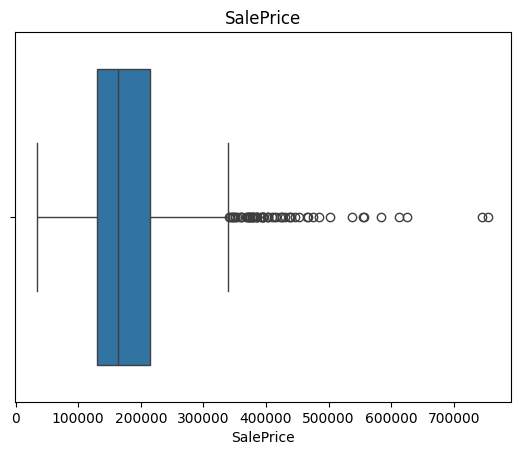

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64','int32','UInt32'] and len(df[col].unique()) != 2:
        plt.figure()
        sns.boxplot(data=df,
                    x=col)
        plt.title(f"{col}")
        plt.show()

###**4.1.2 | INDIVIDUAL BOXPLOTS**

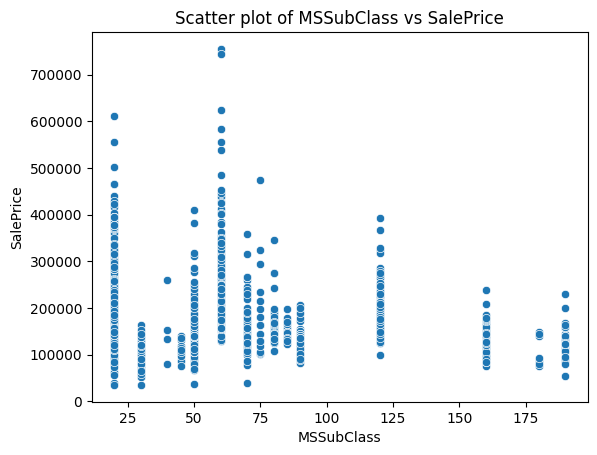

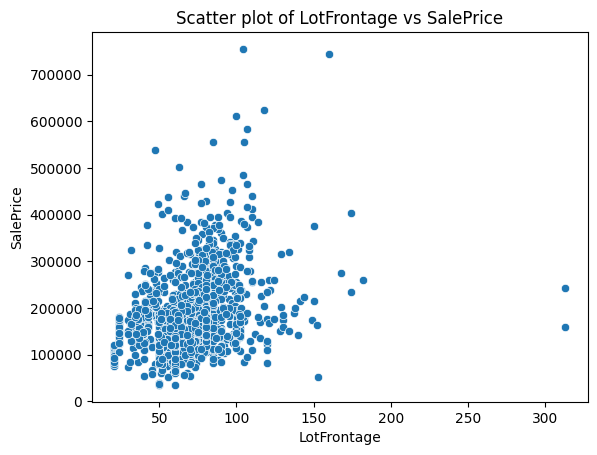

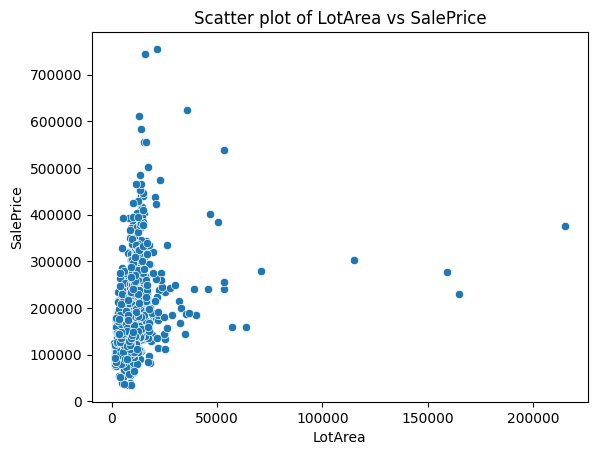

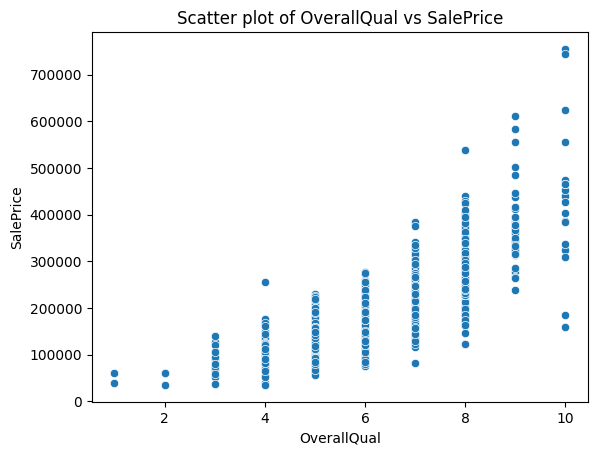

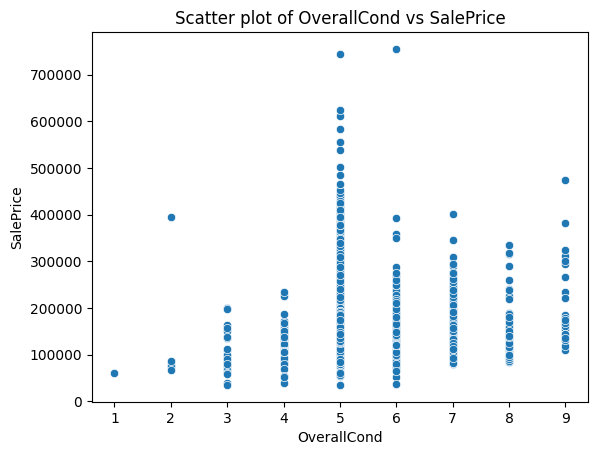

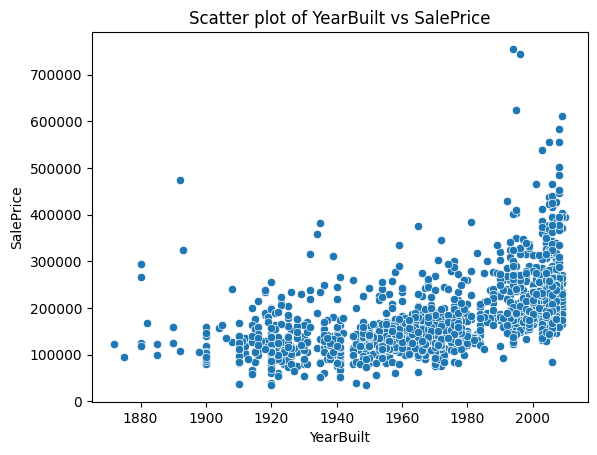

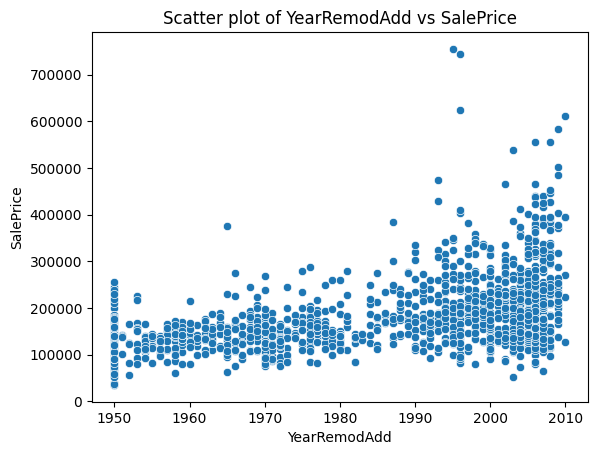

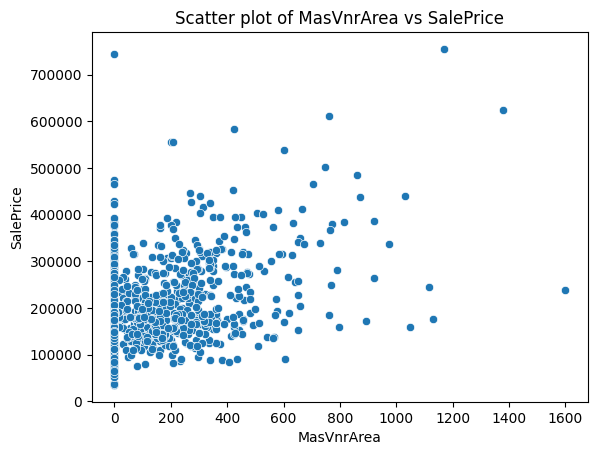

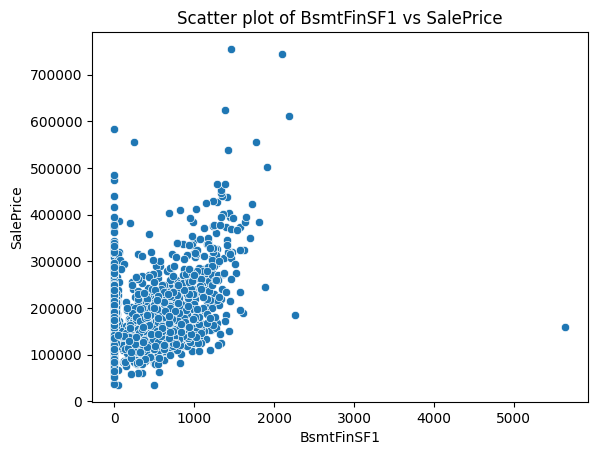

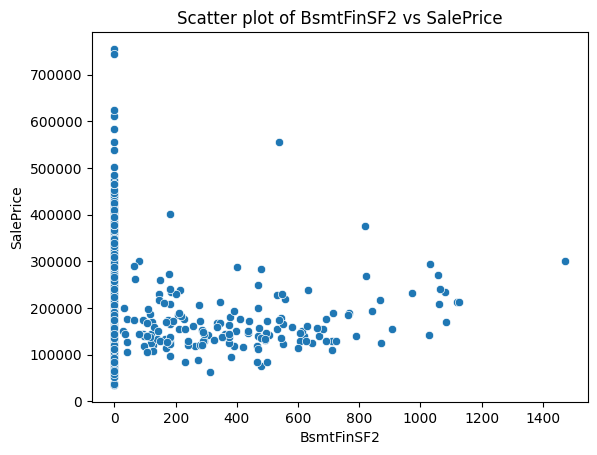

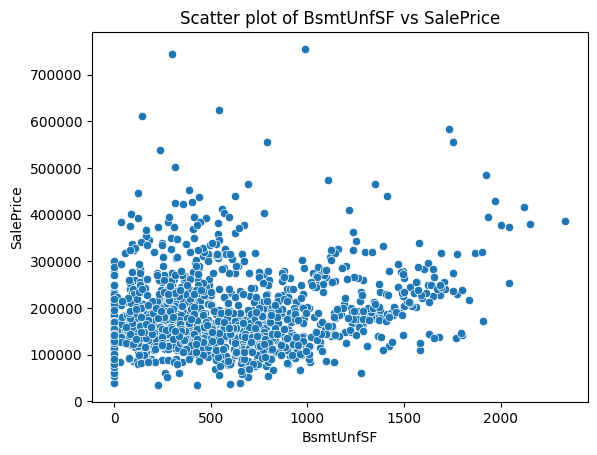

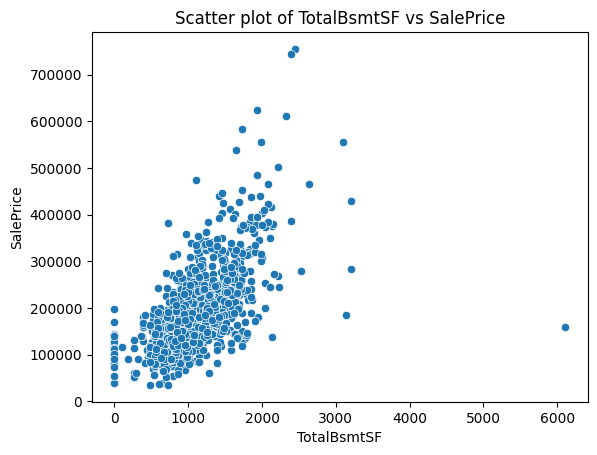

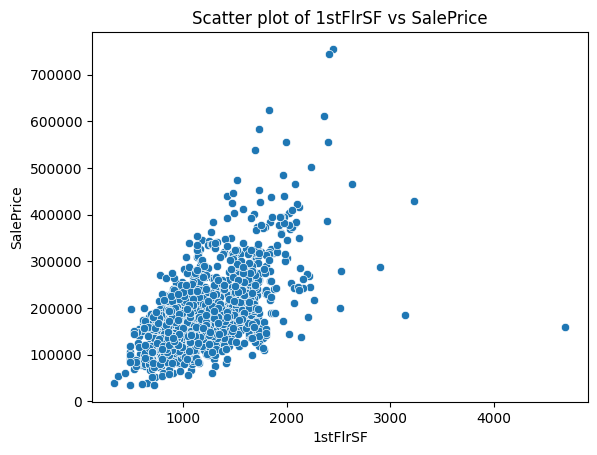

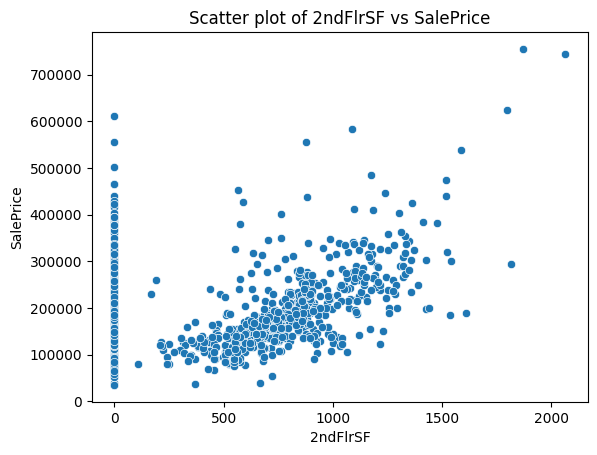

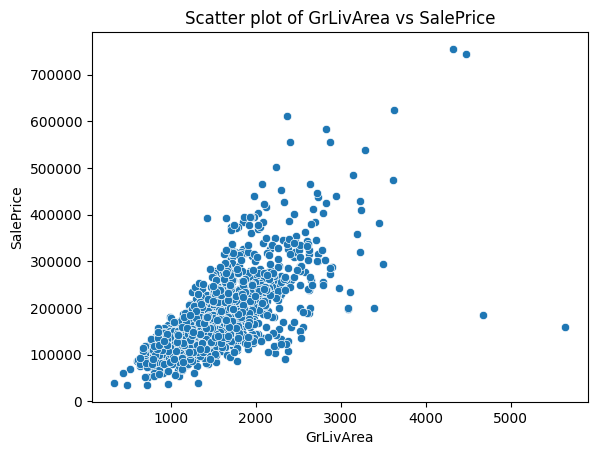

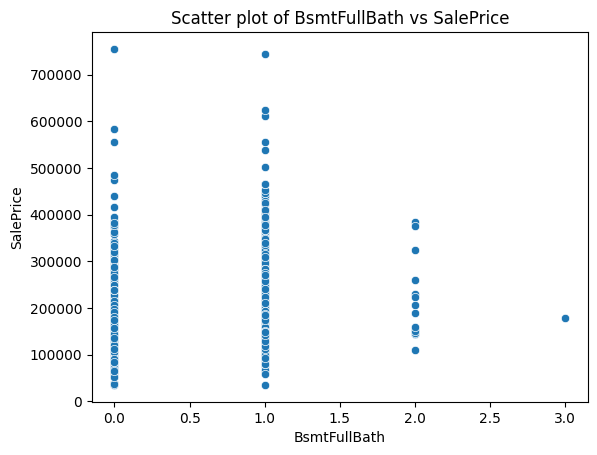

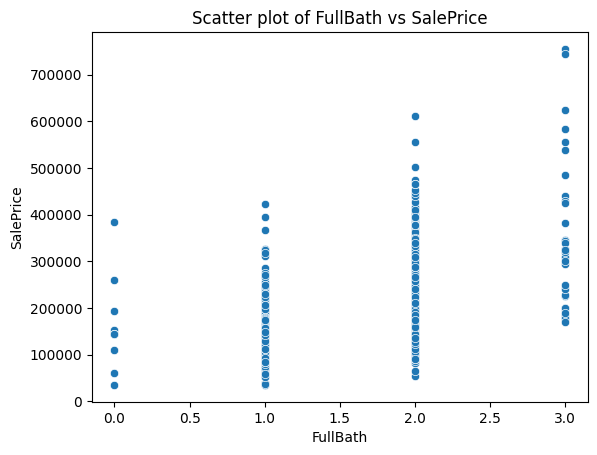

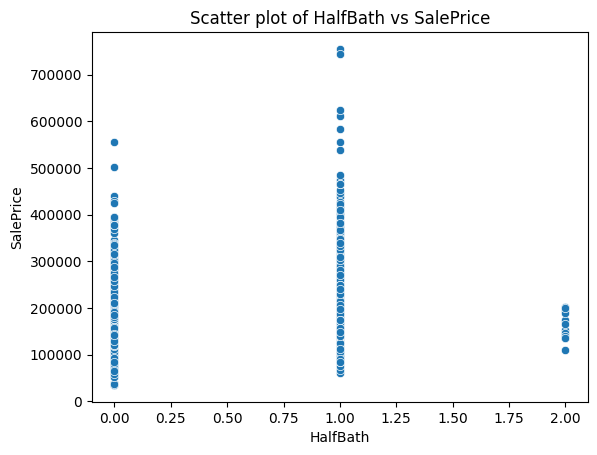

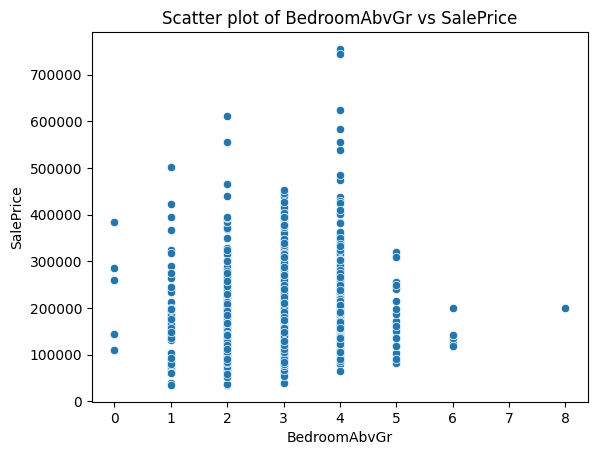

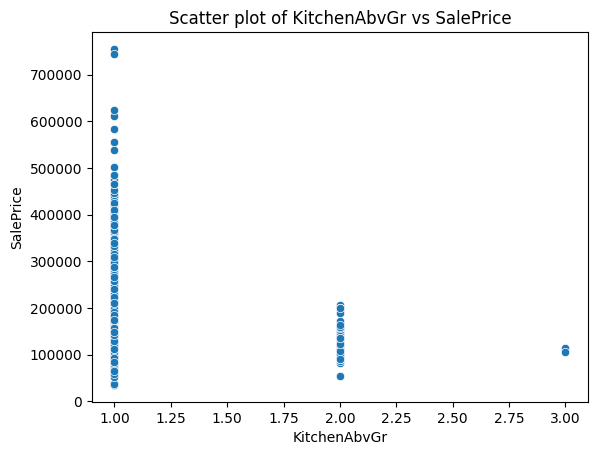

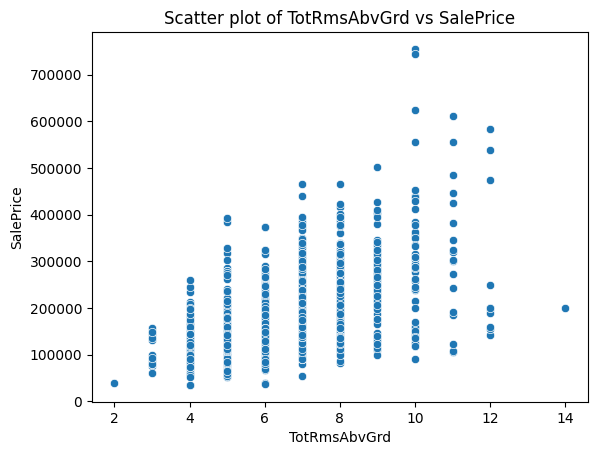

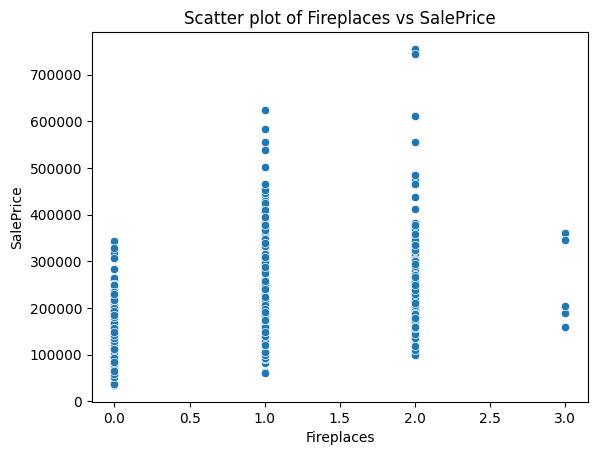

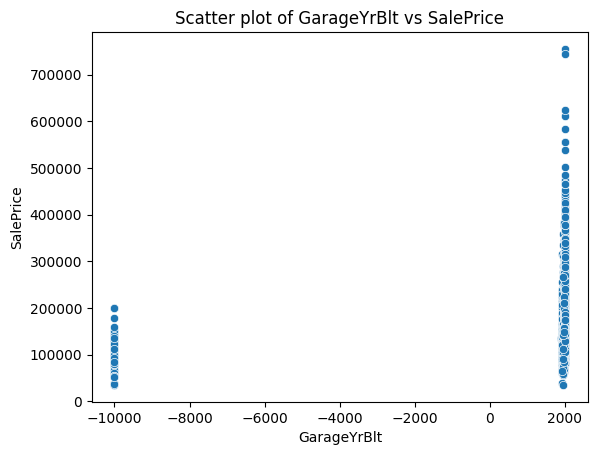

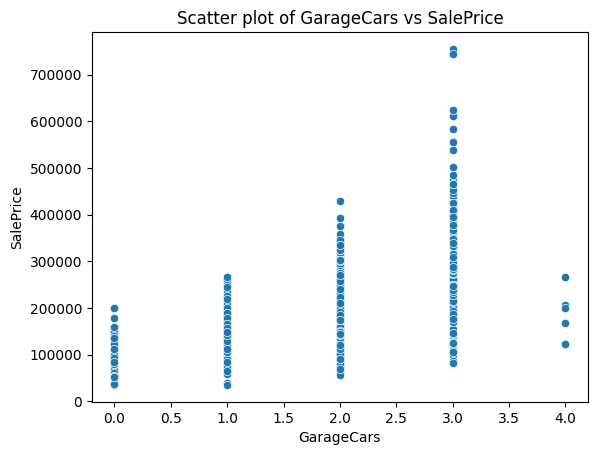

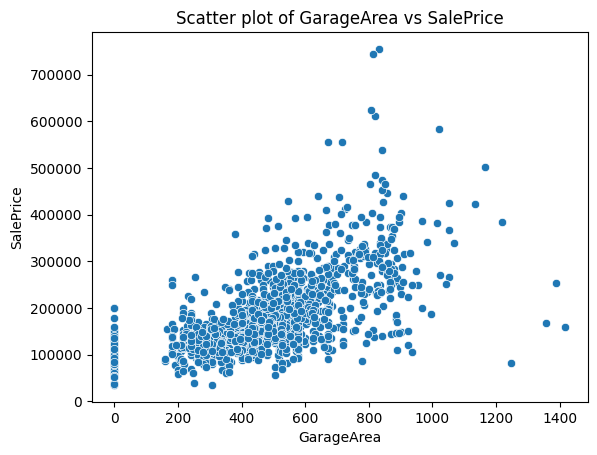

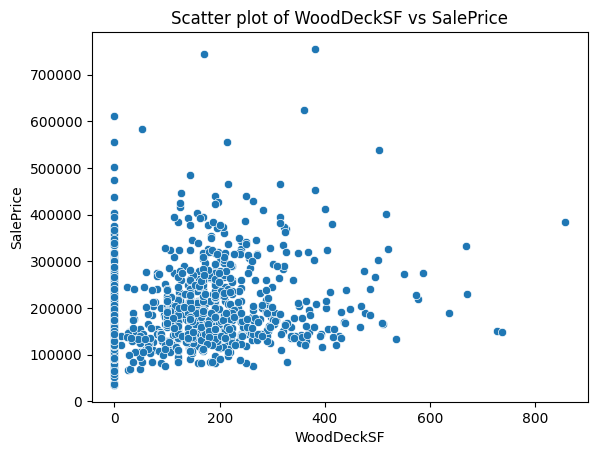

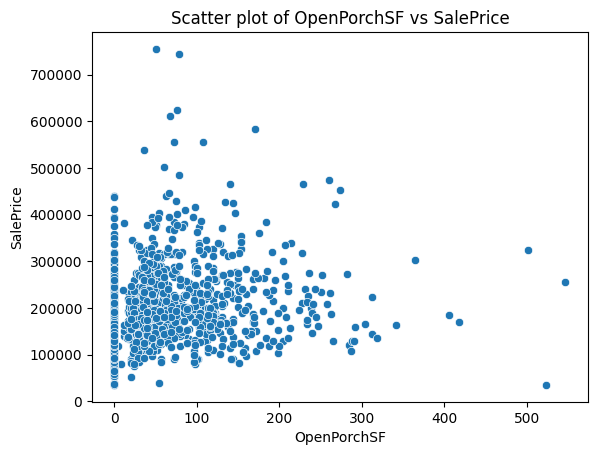

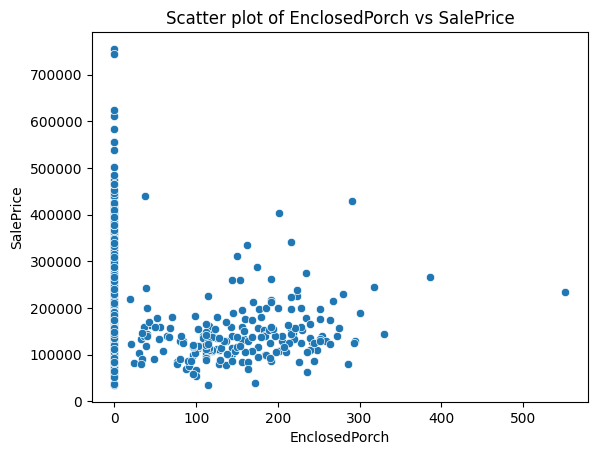

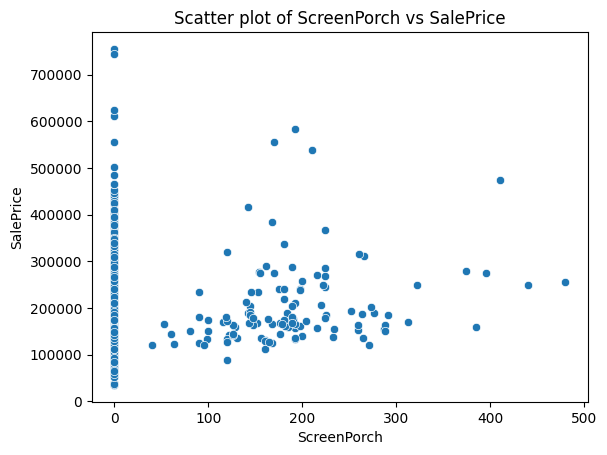

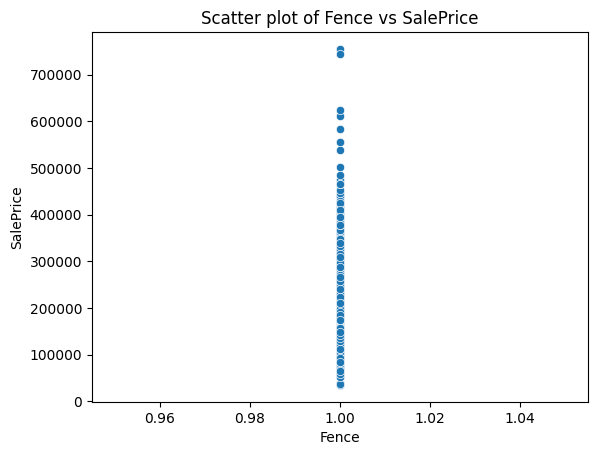

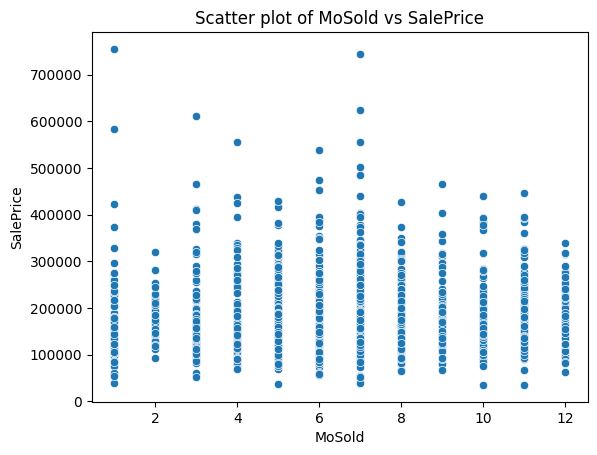

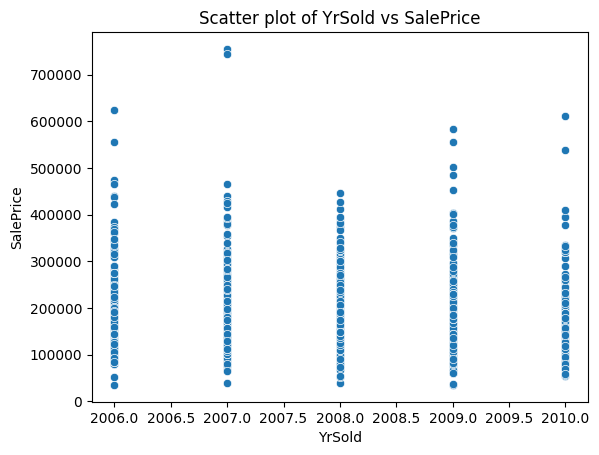

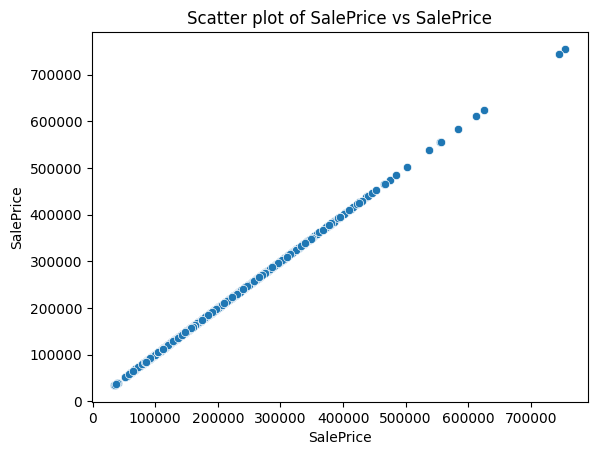

In [ ]:
#NUMERIC
for col in df.columns:
    if df[col].dtype in ['int64', 'float64','int32','UInt32'] and len(df[col].unique()) != 2:
      sns.scatterplot(x=col, y='SalePrice', data=df)
      plt.title(f'Scatter plot of {col} vs SalePrice')
      plt.show()

##**4.2 | CATEGORIC VISUALIZATION**

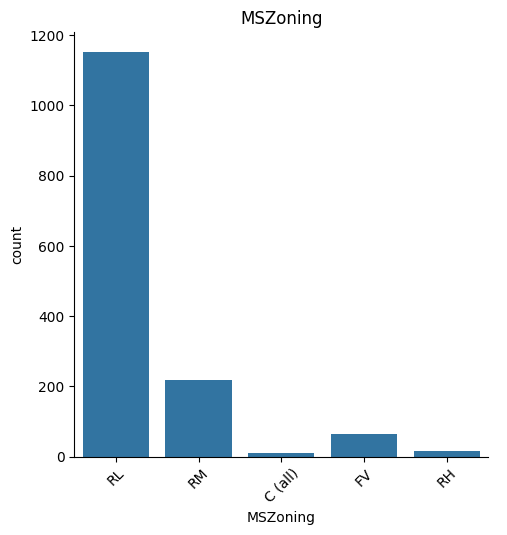

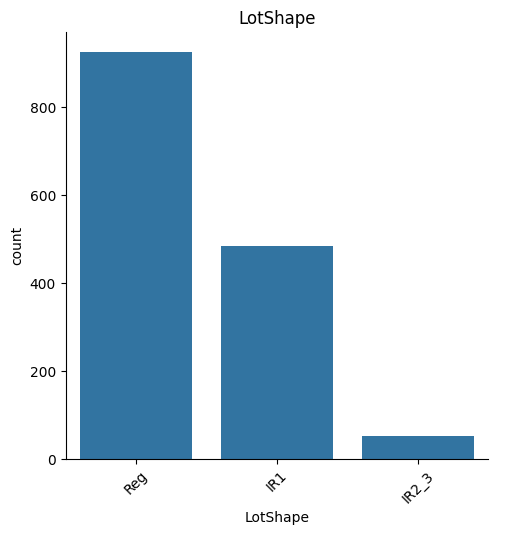

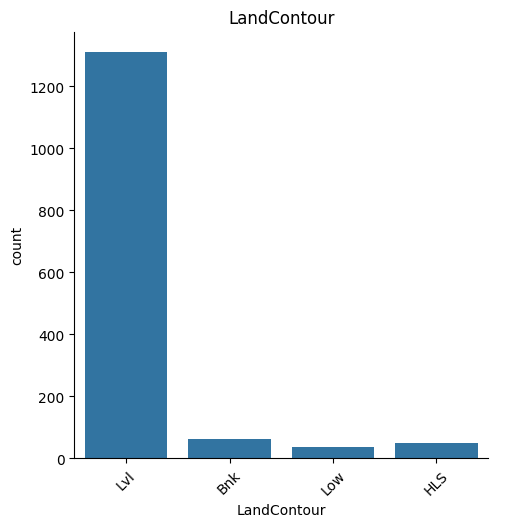

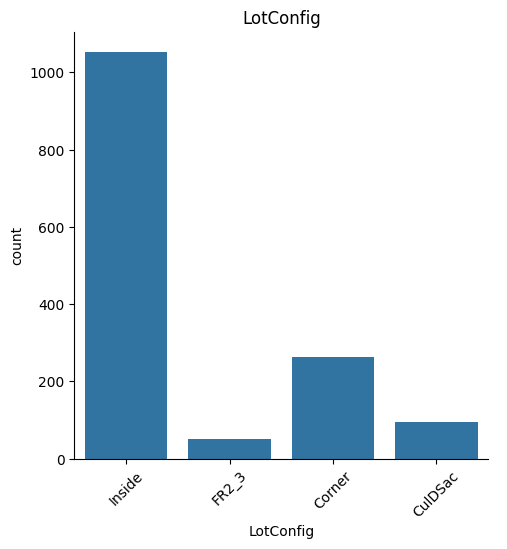

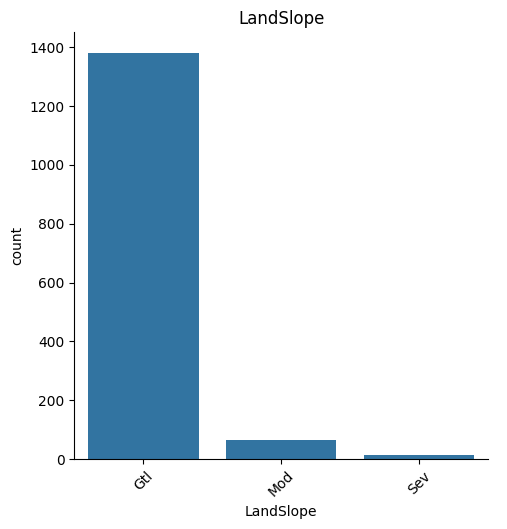

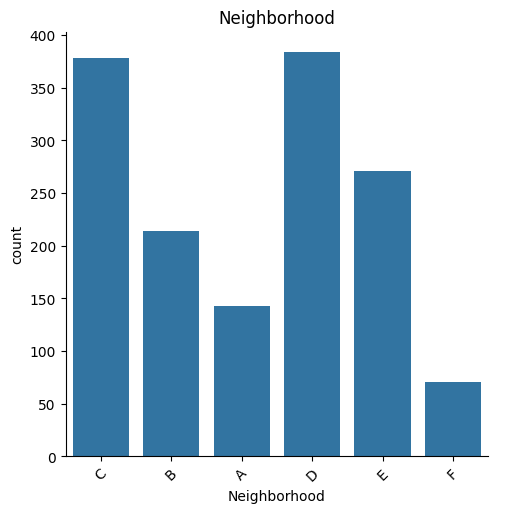

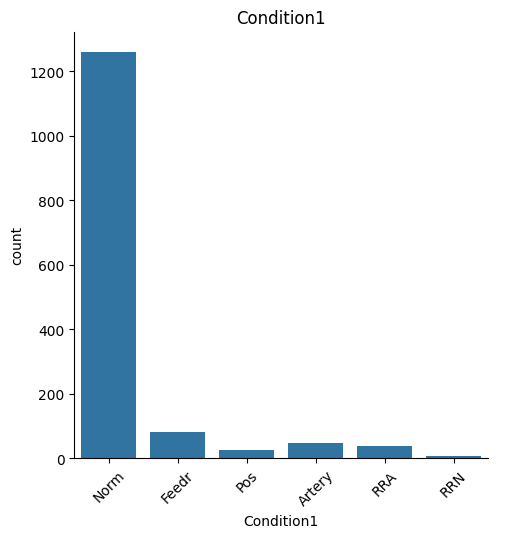

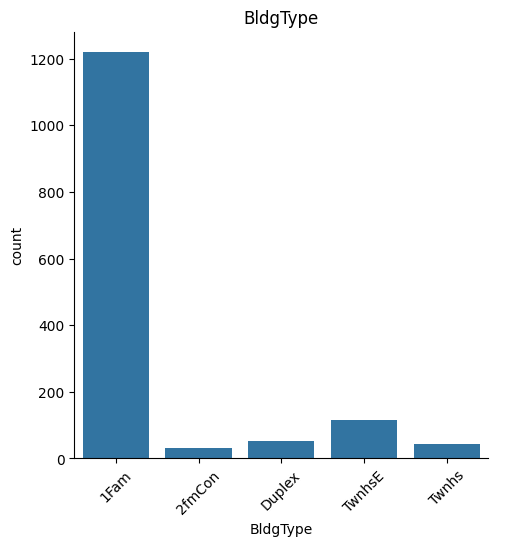

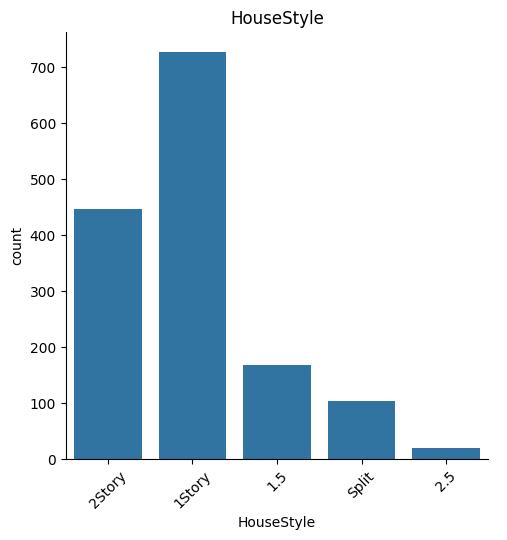

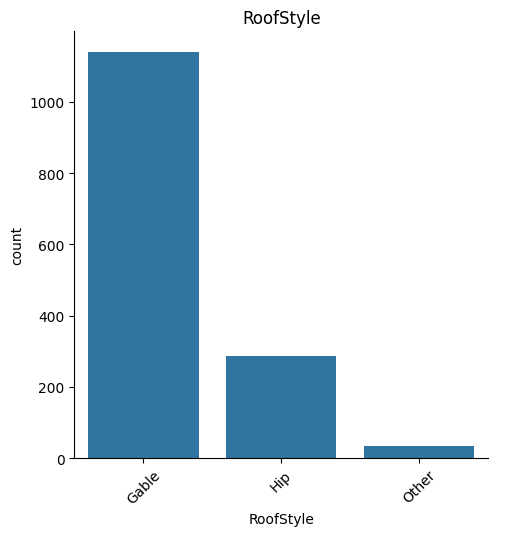

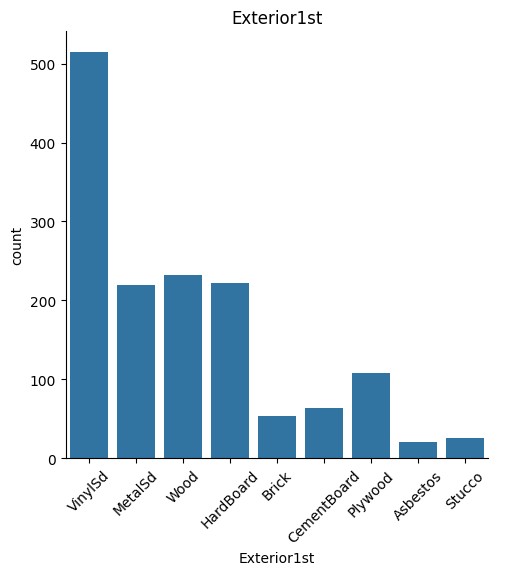

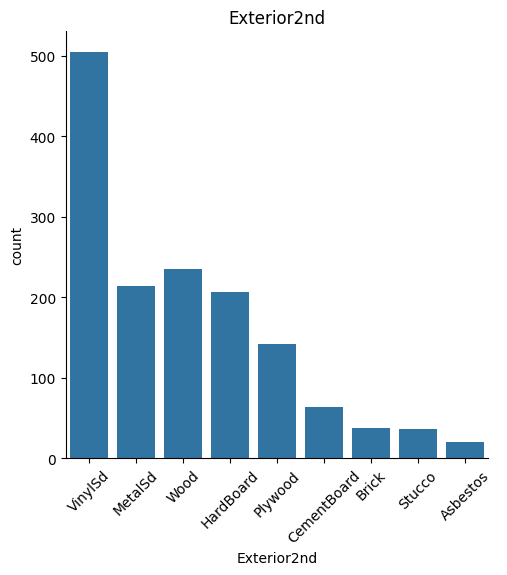

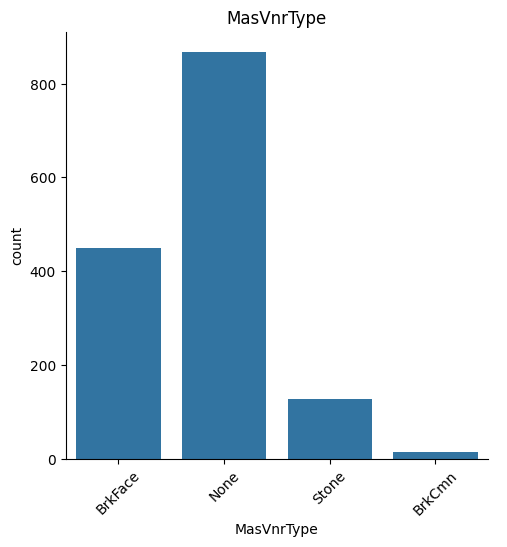

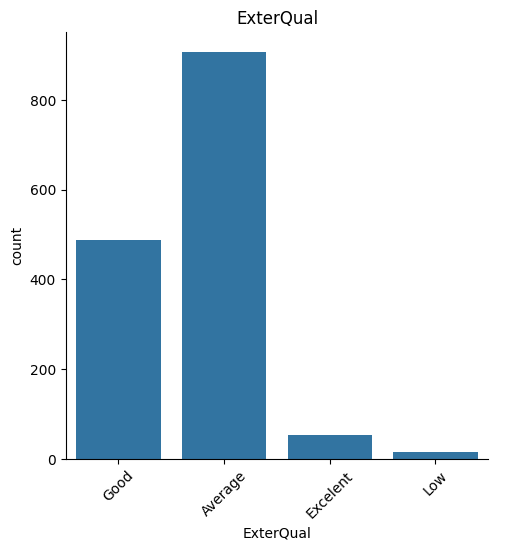

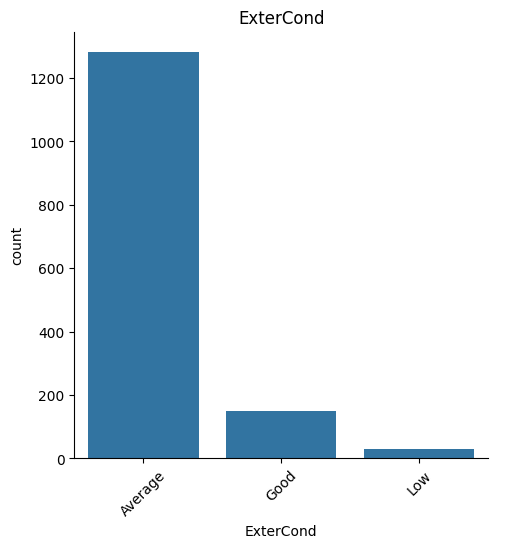

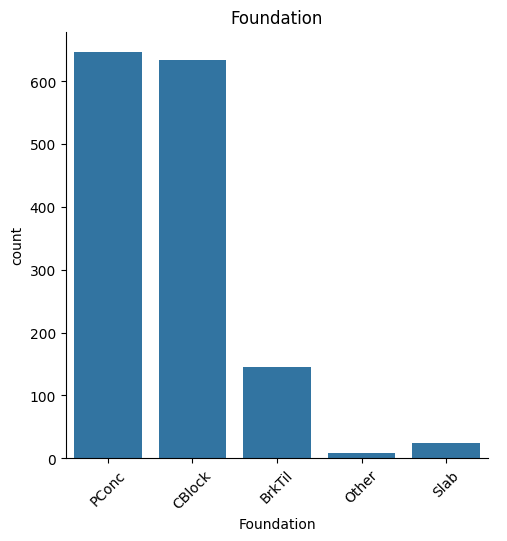

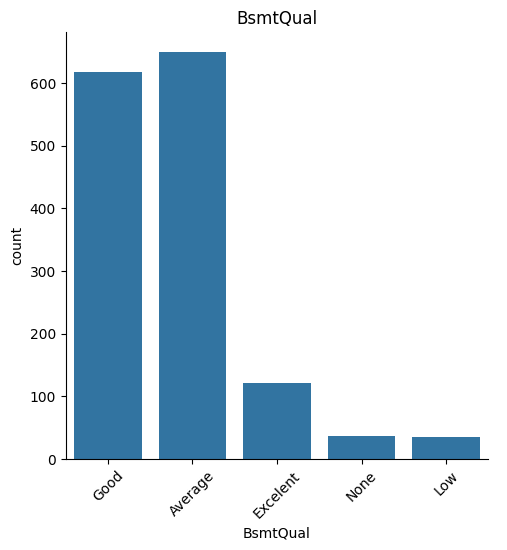

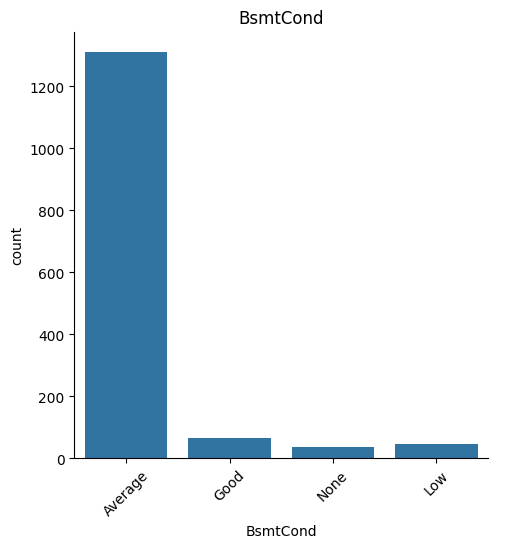

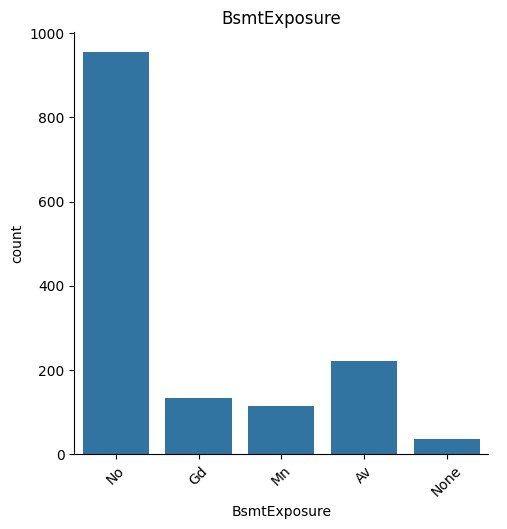

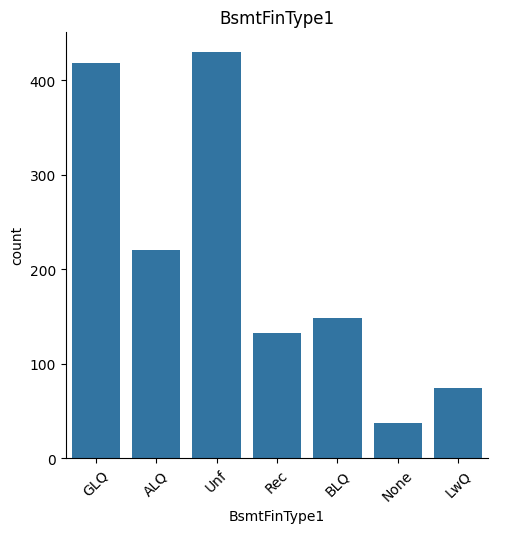

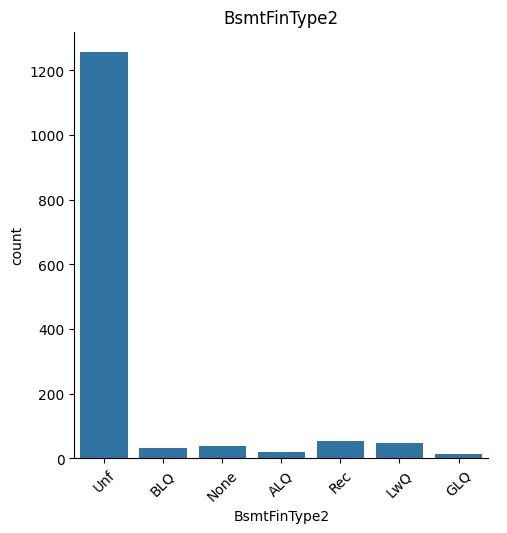

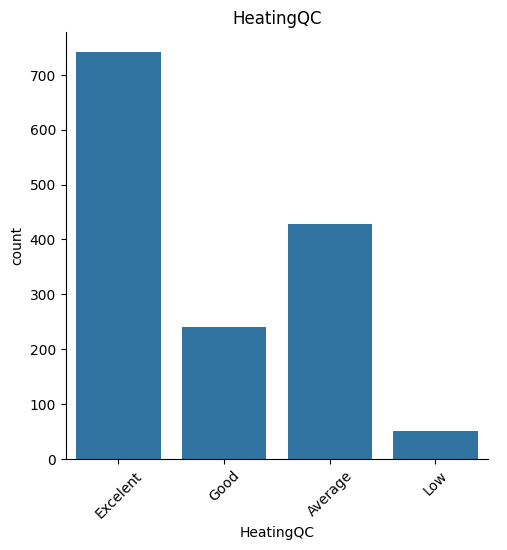

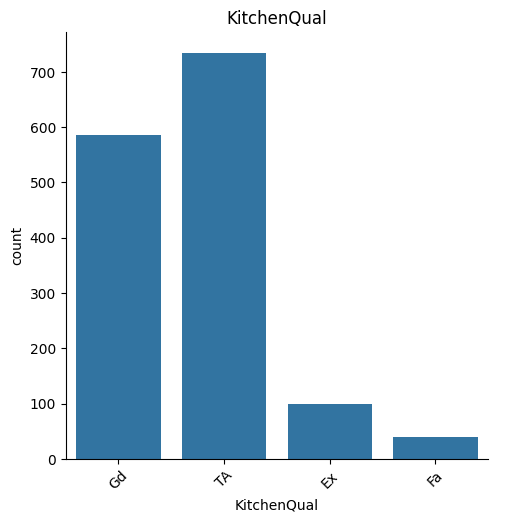

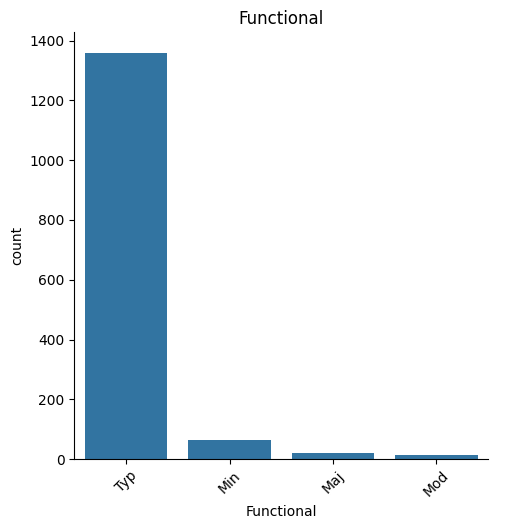

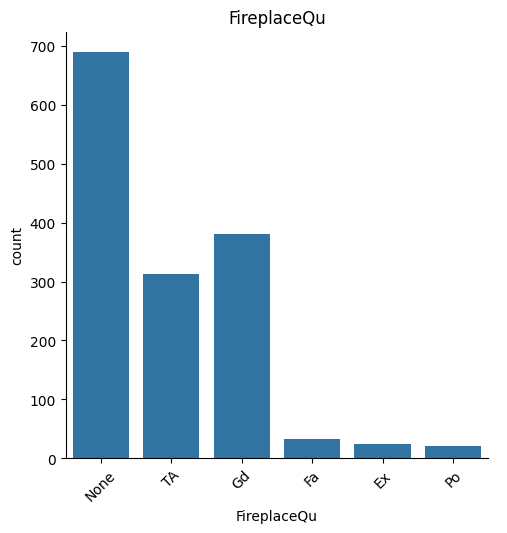

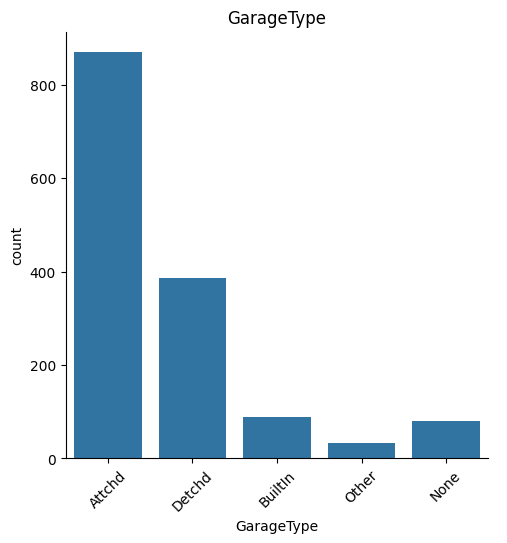

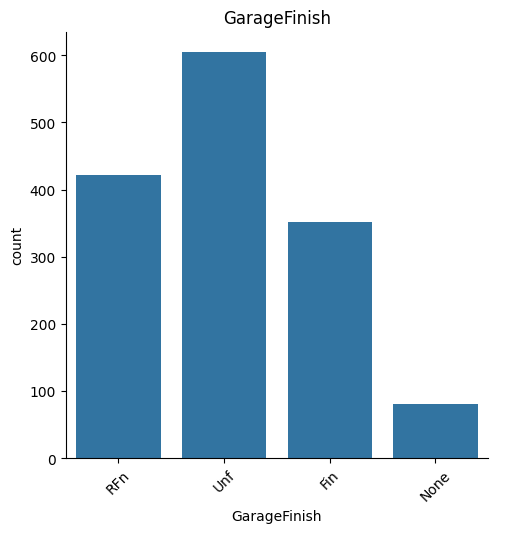

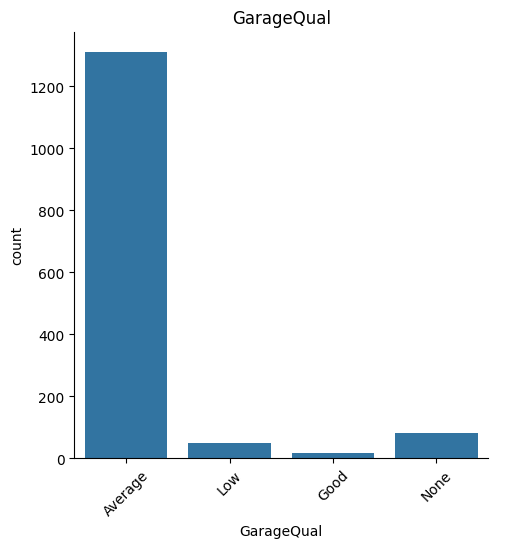

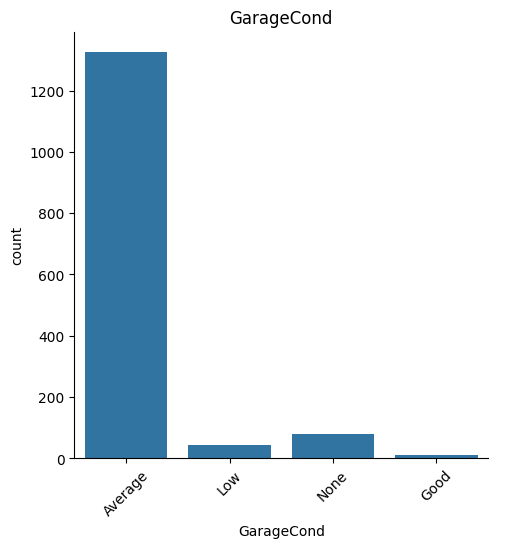

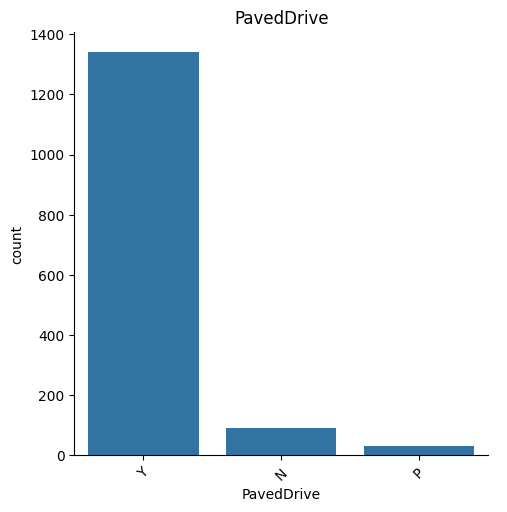

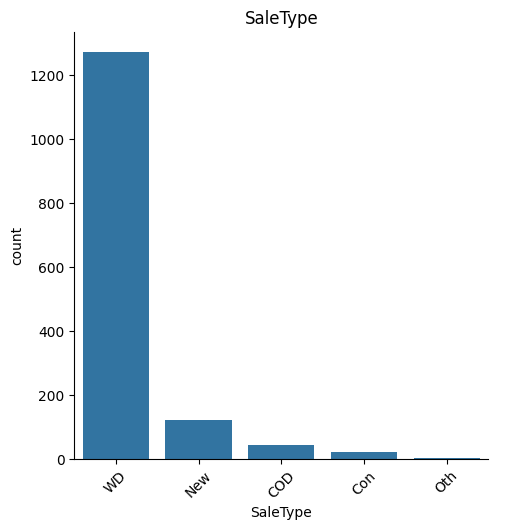

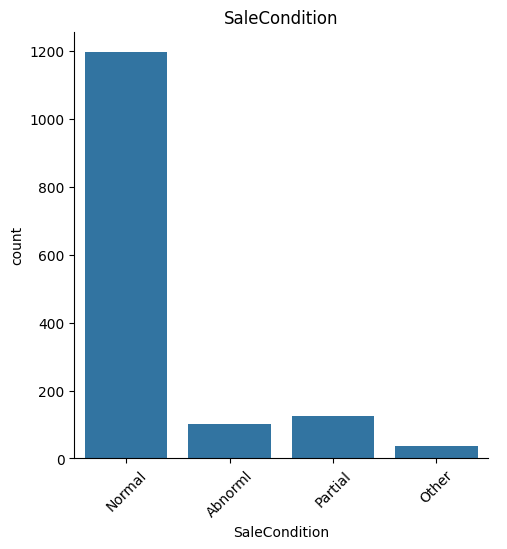

In [ ]:
for col in df.columns:
    if df[col].dtype == 'O':
        sns.catplot(data=df,
                    x=col,
                    kind='count')
        plt.title(f"{col}")
        plt.xticks(rotation=45)
        plt.show()

##**4.3 | BOOLEAN VISUALIZATION**

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and len(df[col].unique()) == 2:
        plt.figure()
        sns.catplot(data=df,
                    x=col,
                    kind = 'count');
        plt.title(f"{col}")
        plt.show()

##**4.4 | FEATURES vs TARGET**

###**4.4.1 | NUMERIC**

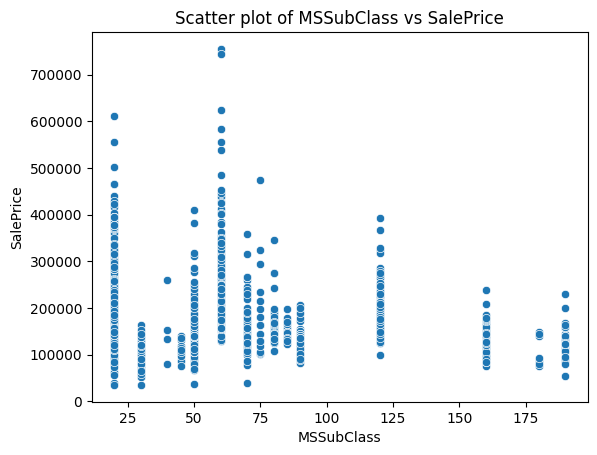

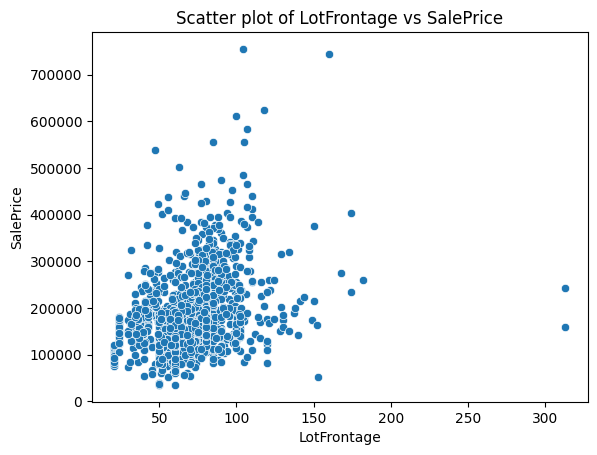

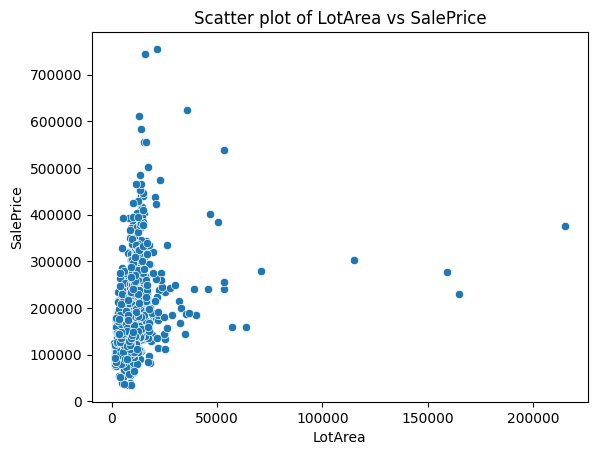

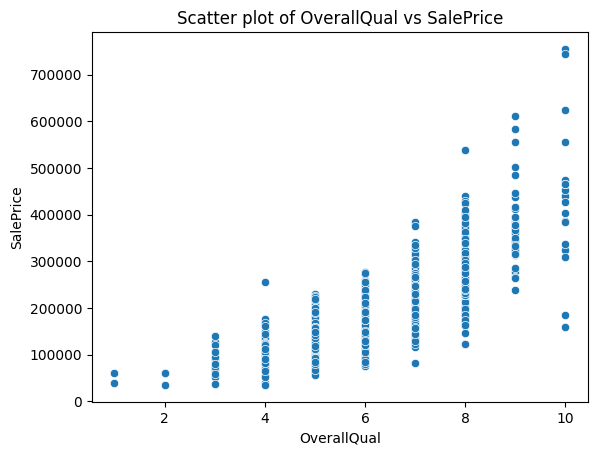

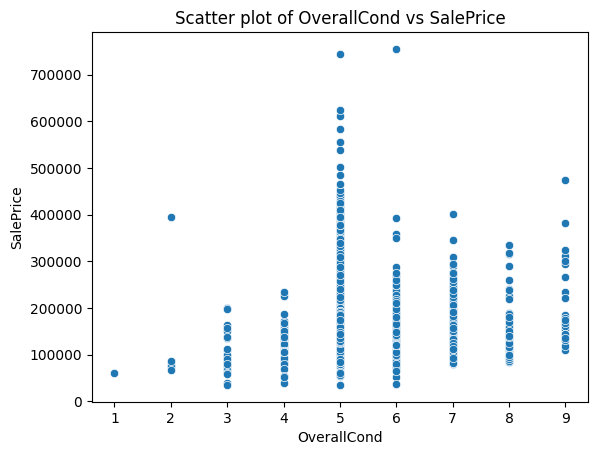

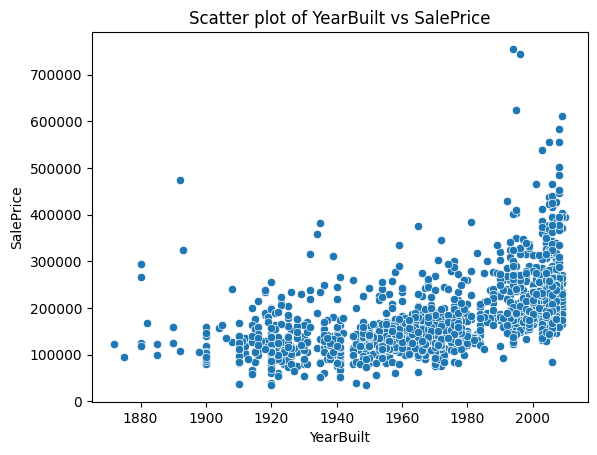

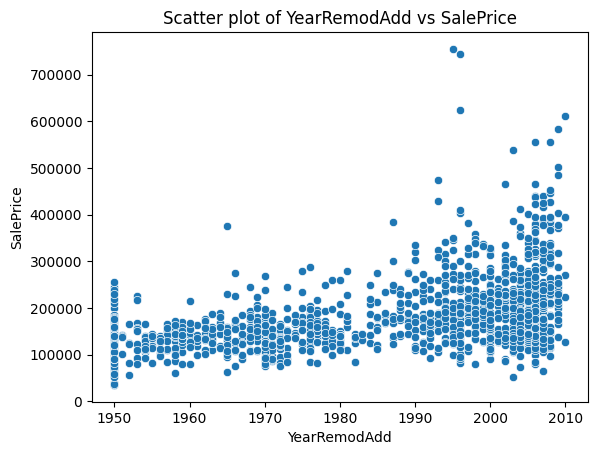

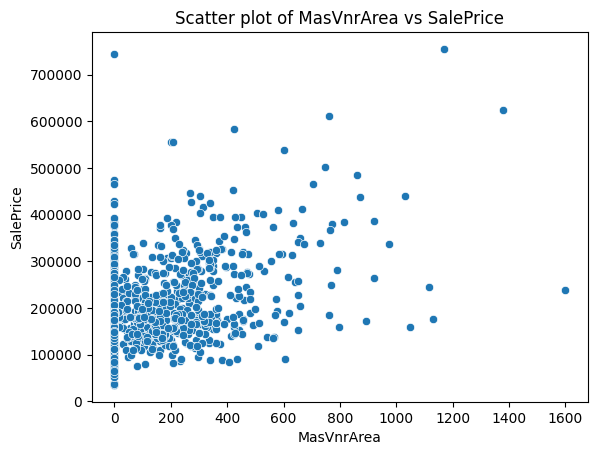

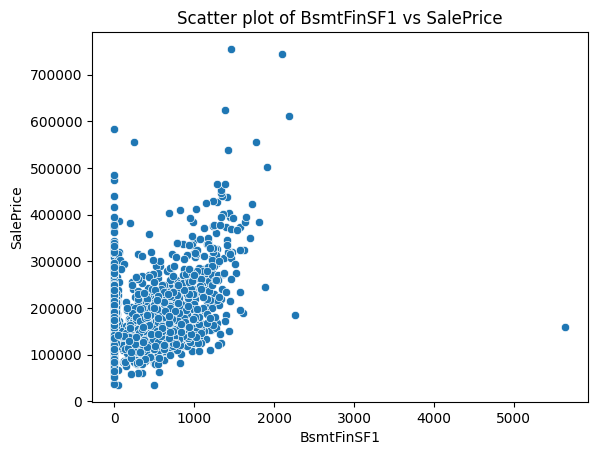

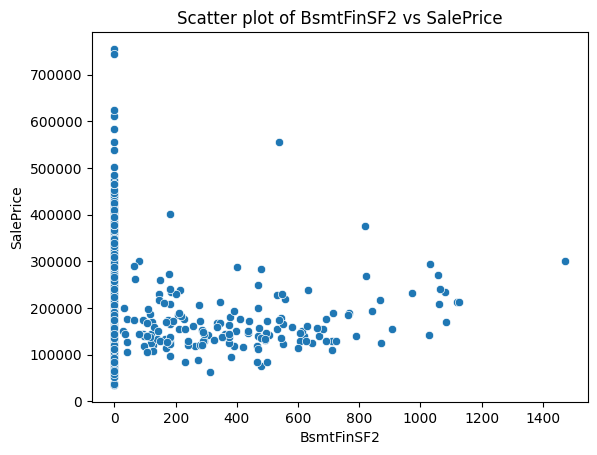

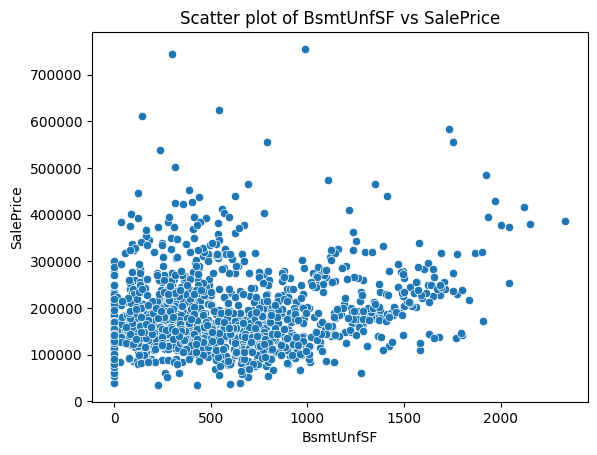

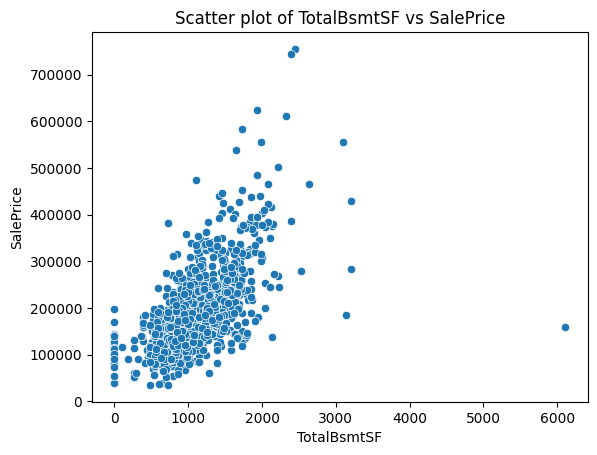

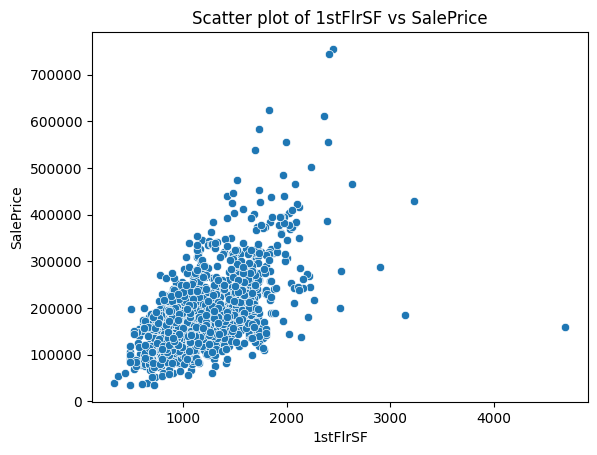

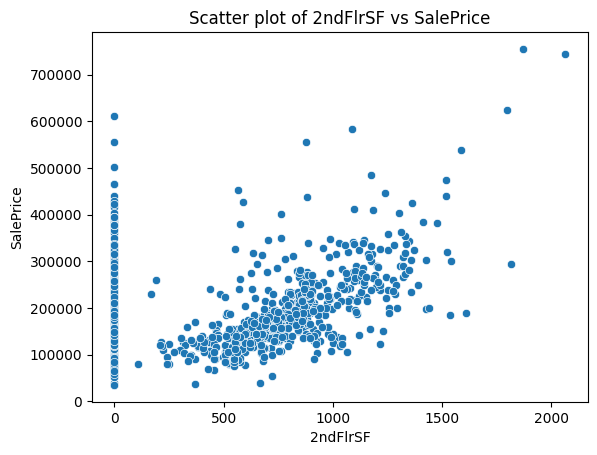

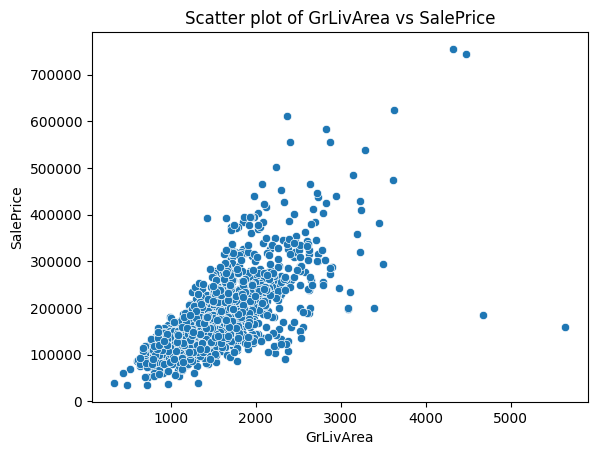

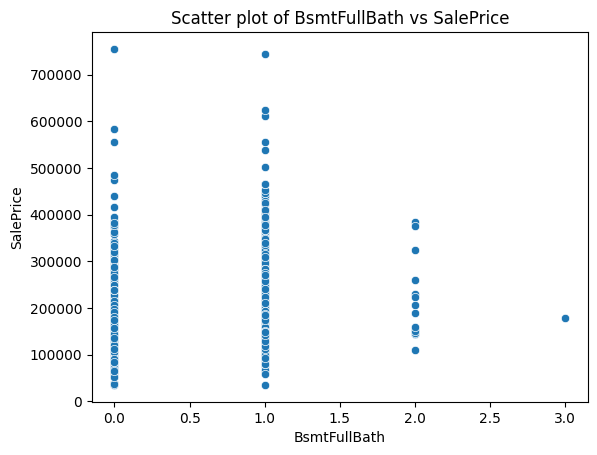

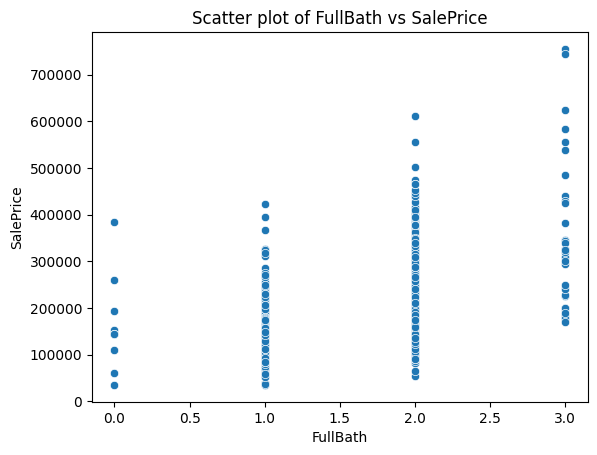

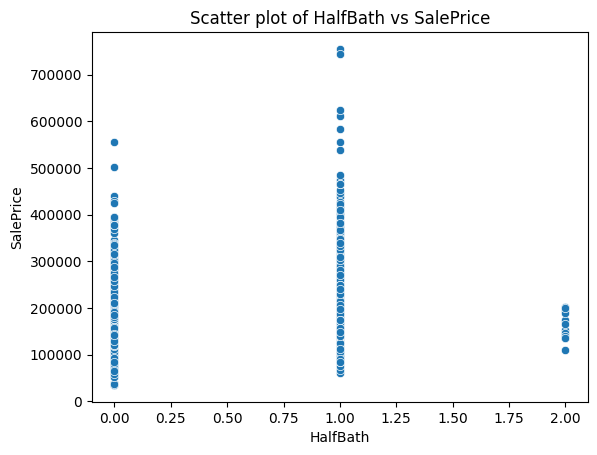

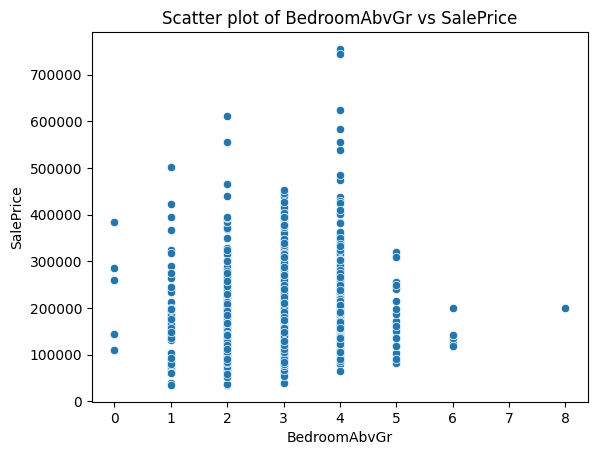

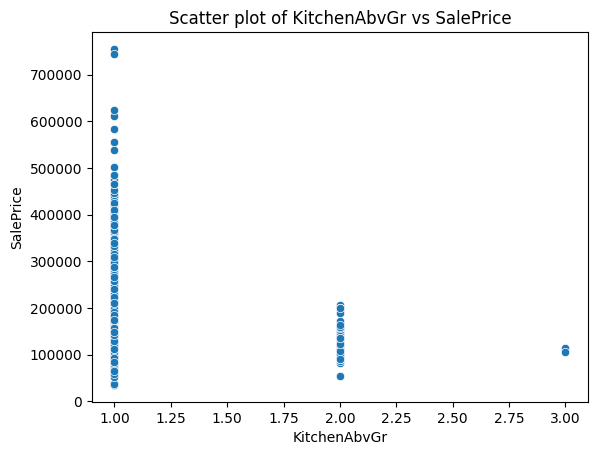

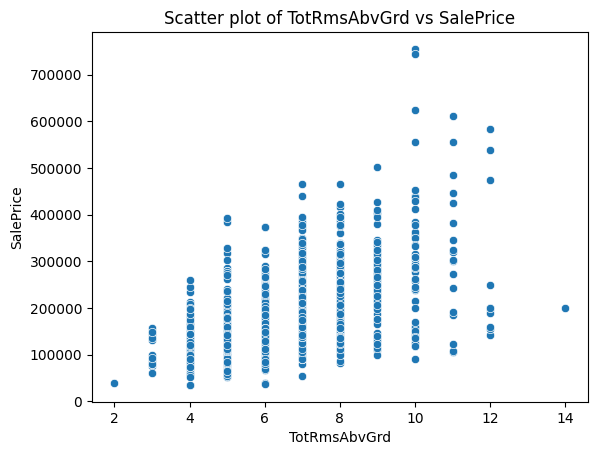

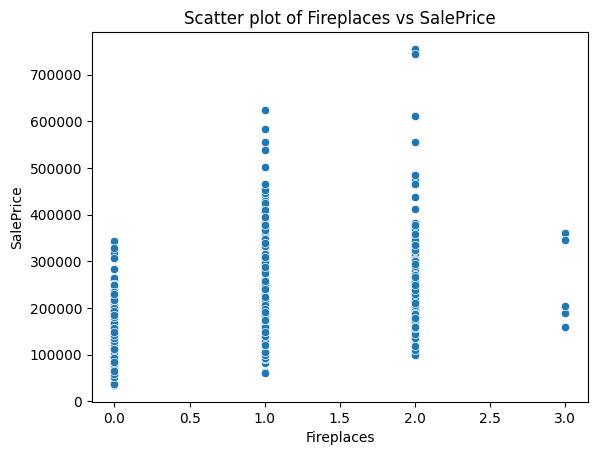

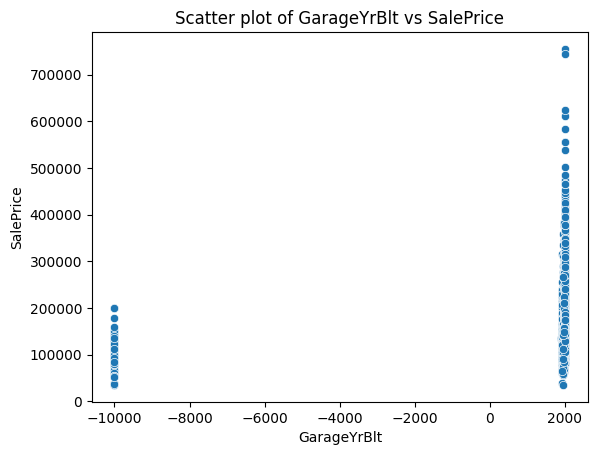

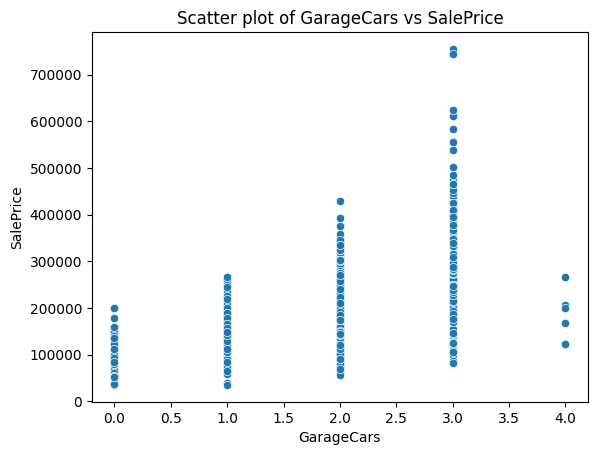

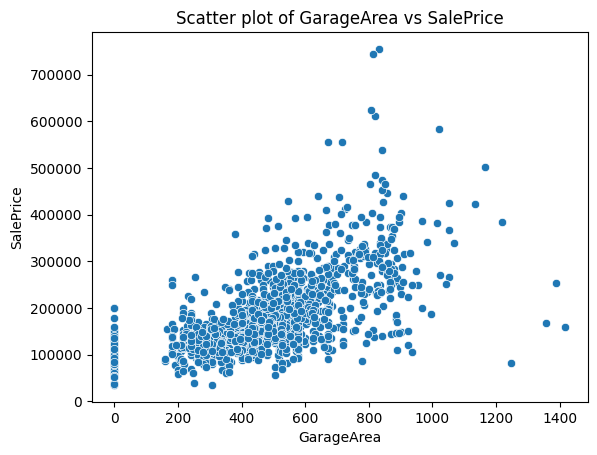

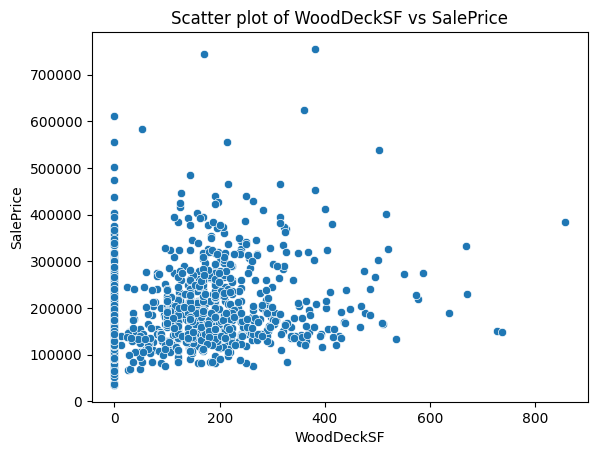

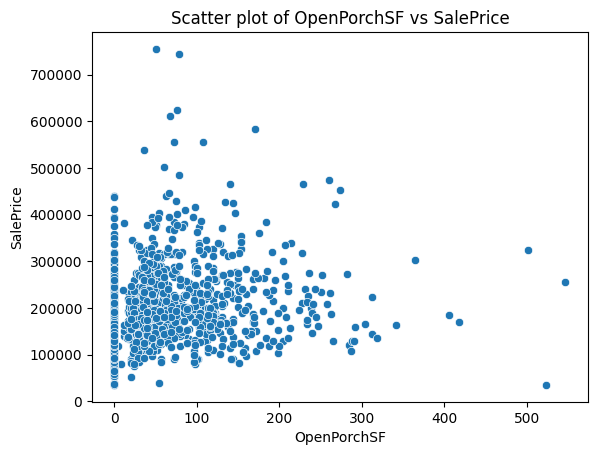

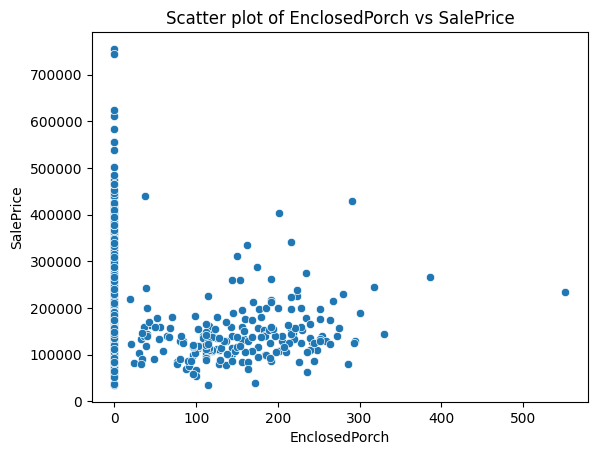

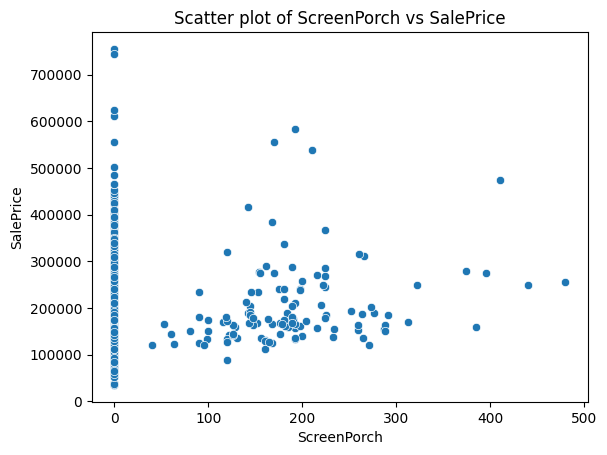

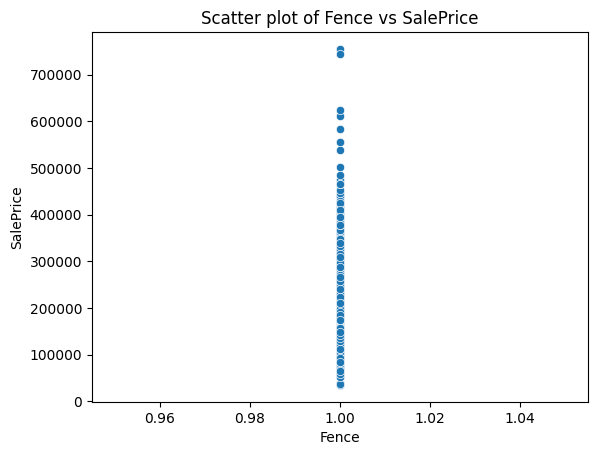

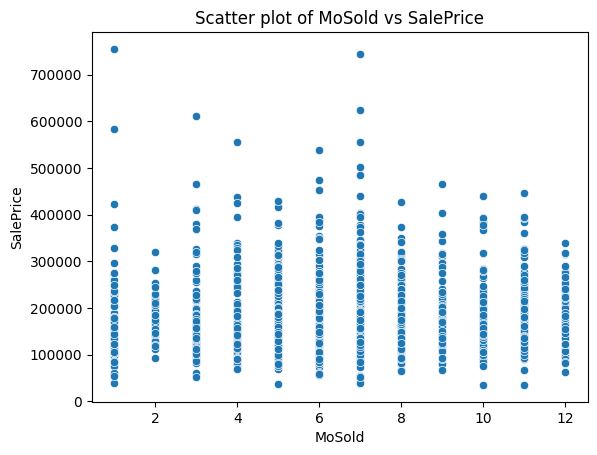

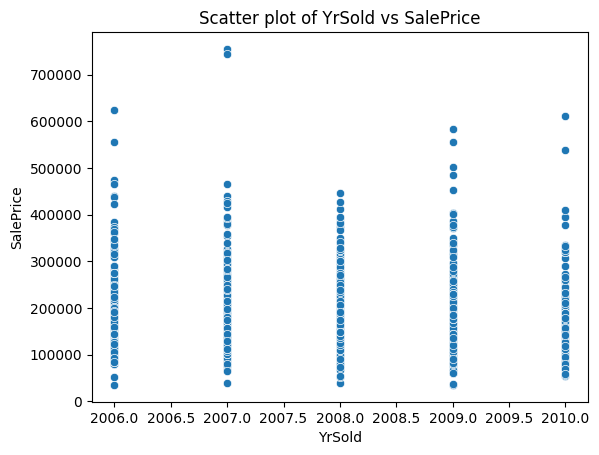

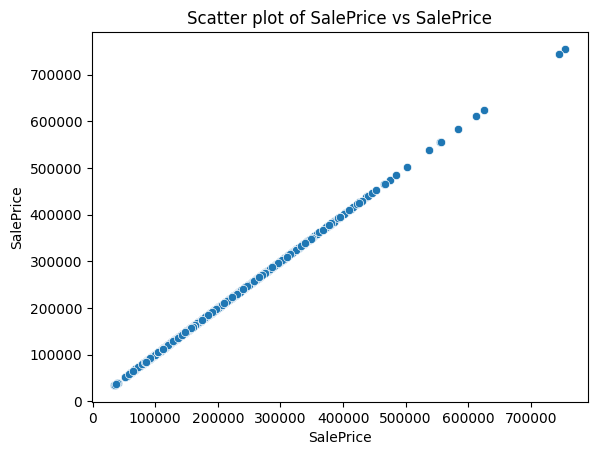

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64','int32','UInt32'] and len(df[col].unique()) != 2:
      sns.scatterplot(x=col, y='SalePrice', data=df)
      plt.title(f'Scatter plot of {col} vs SalePrice')
      plt.show()

###**4.4.2 | BOOL**

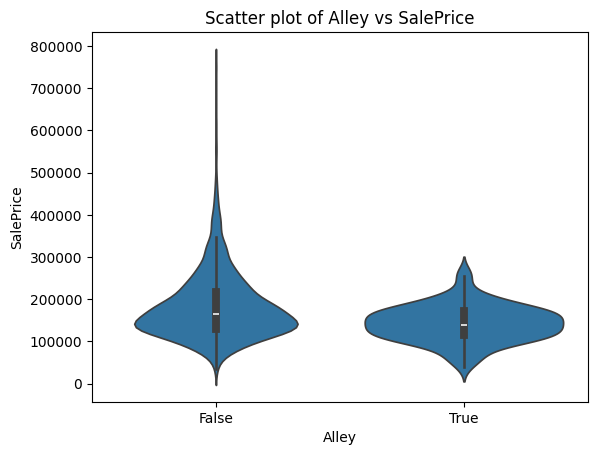

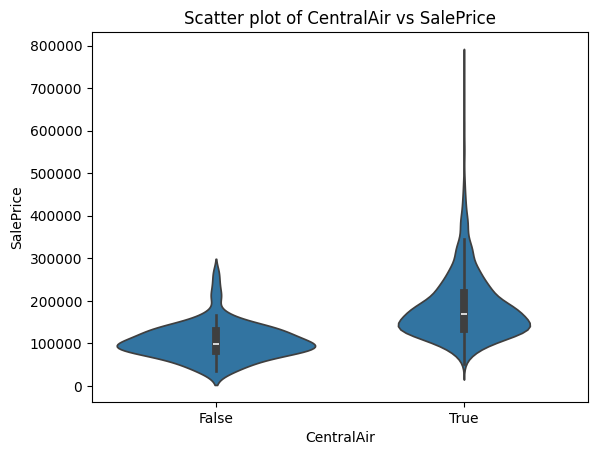

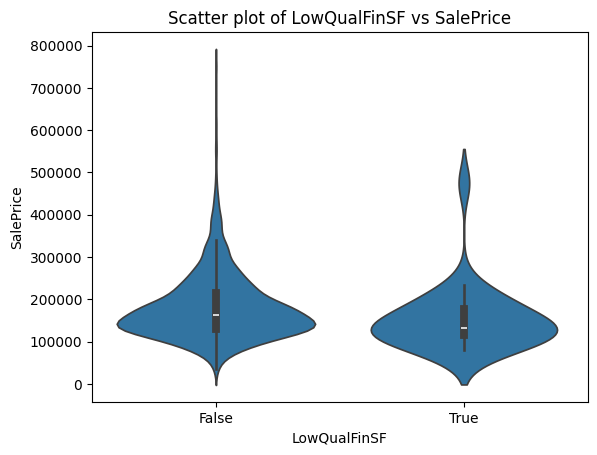

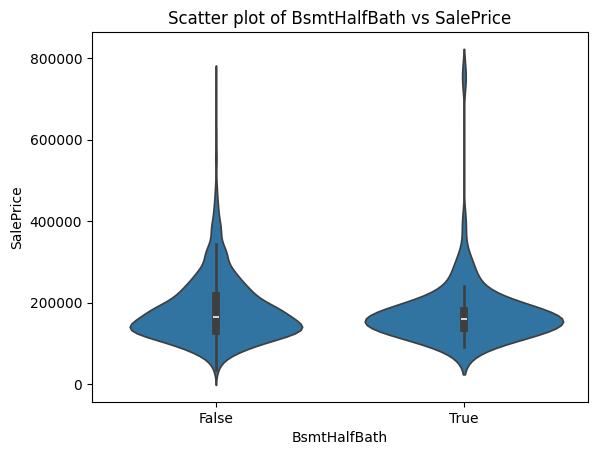

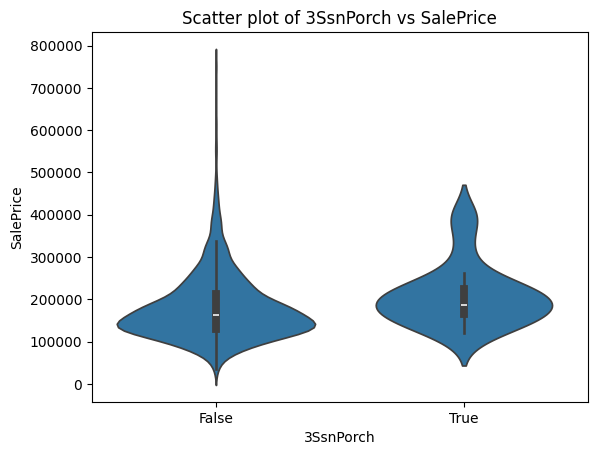

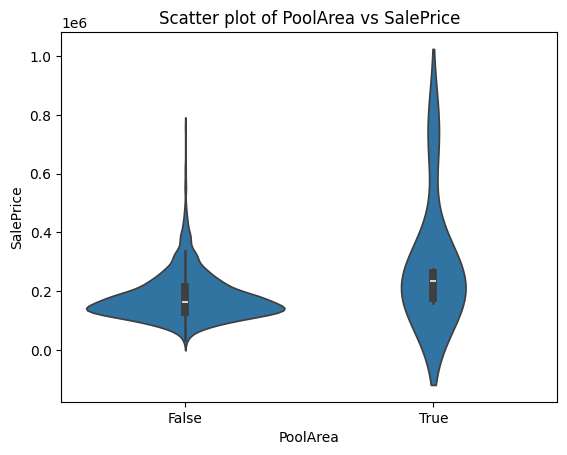

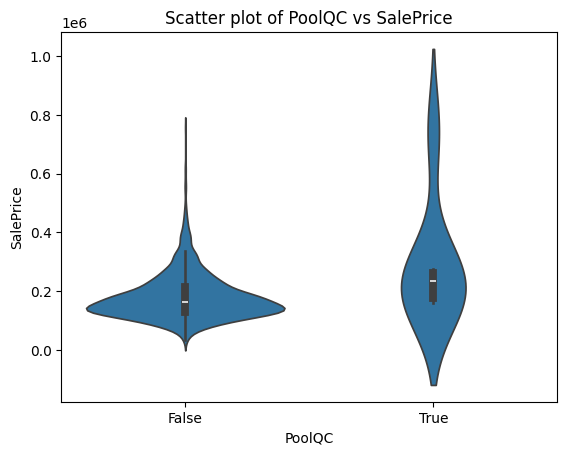

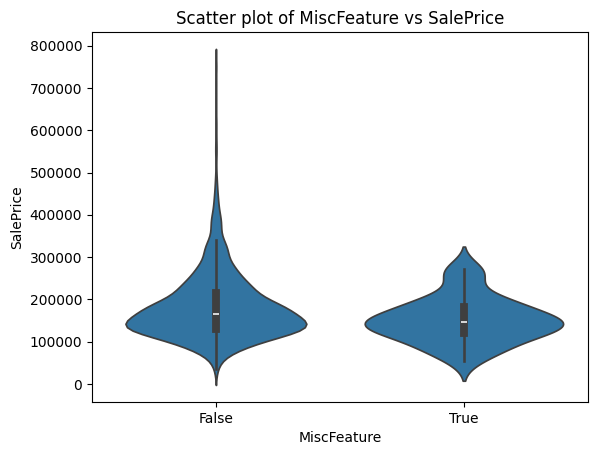

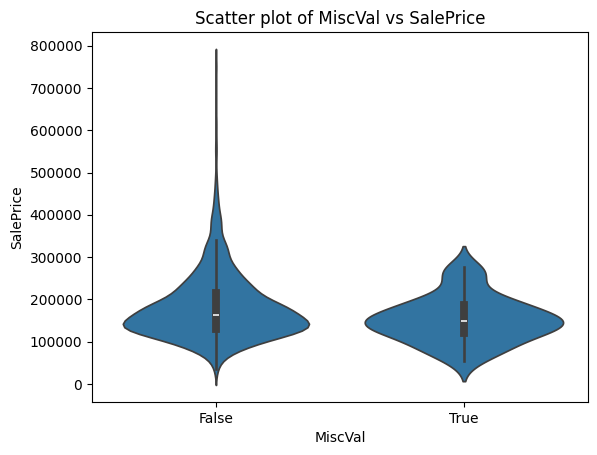

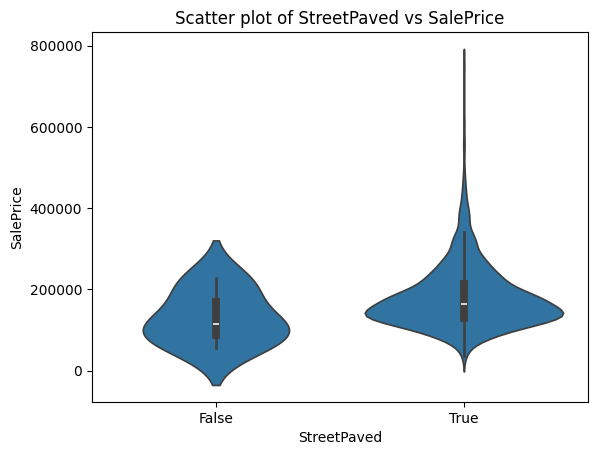

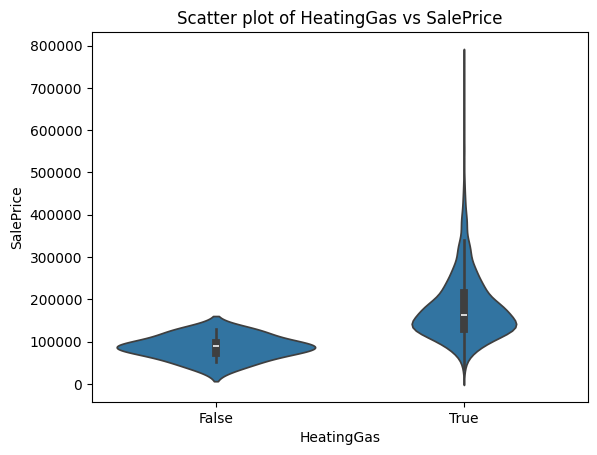

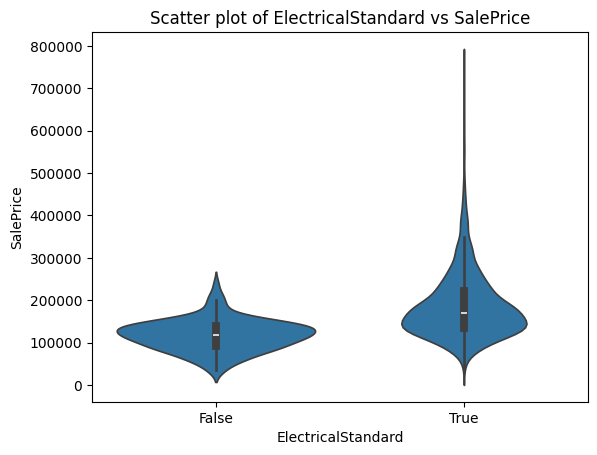

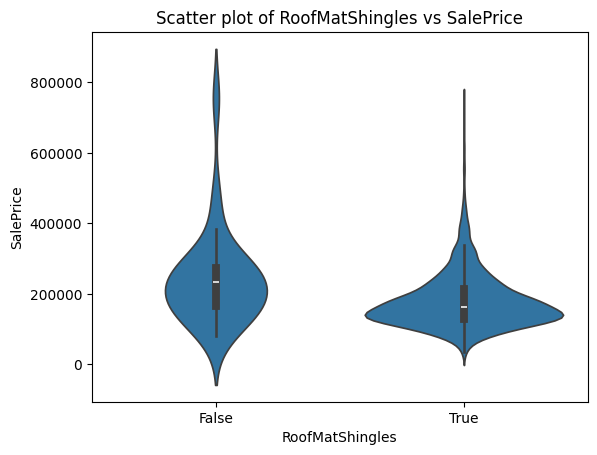

In [ ]:
#VIOLINPLOT
for col in df.columns:
    if len(df[col].unique()) == 2:
      sns.violinplot(x=col, y='SalePrice', data=df)
      plt.title(f'Scatter plot of {col} vs SalePrice')
      plt.show()

###**4.4.1 | CATEGORIC**

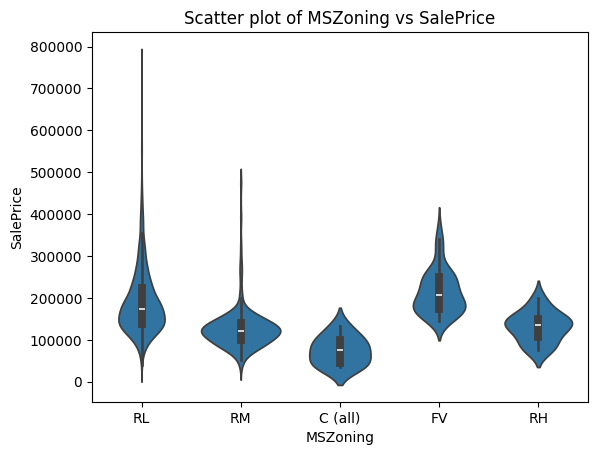

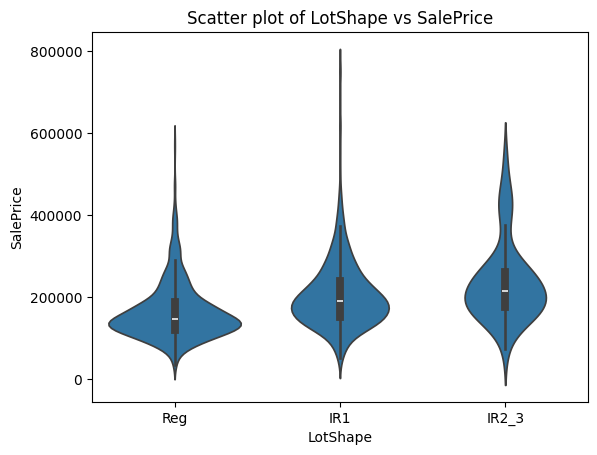

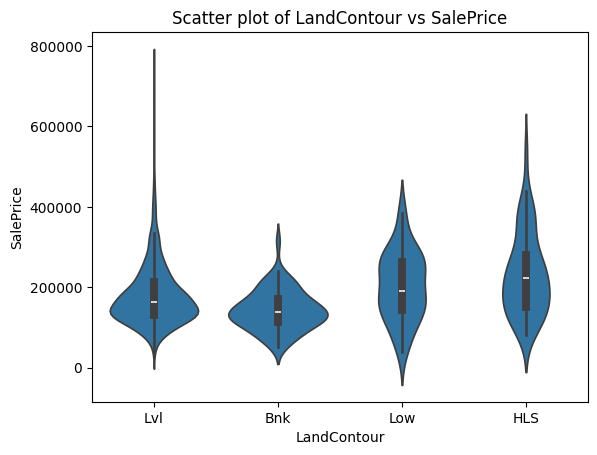

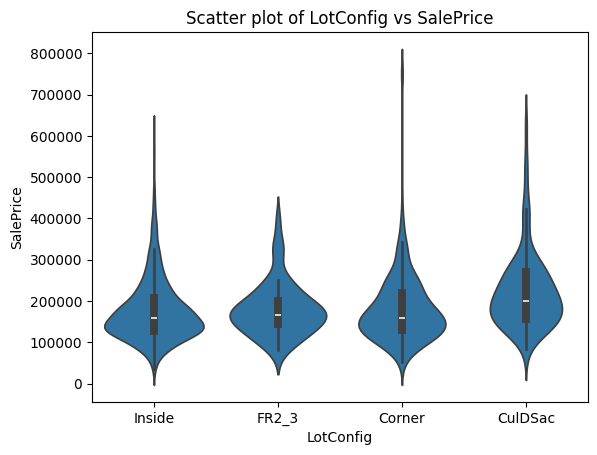

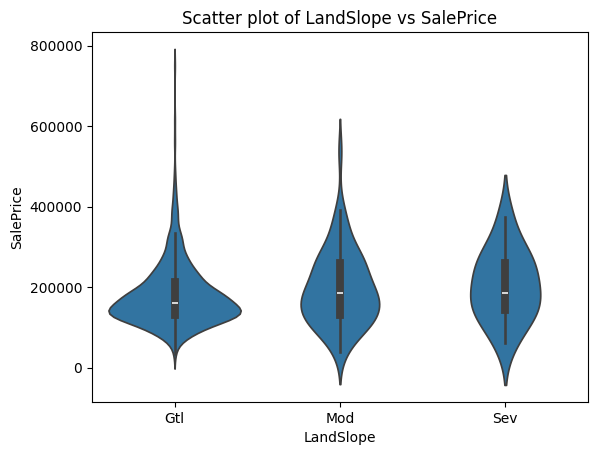

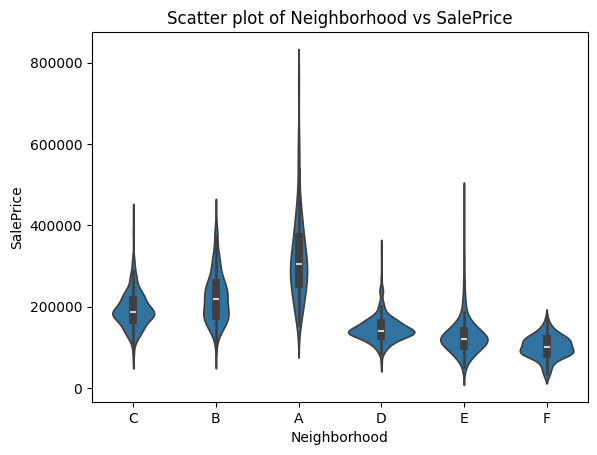

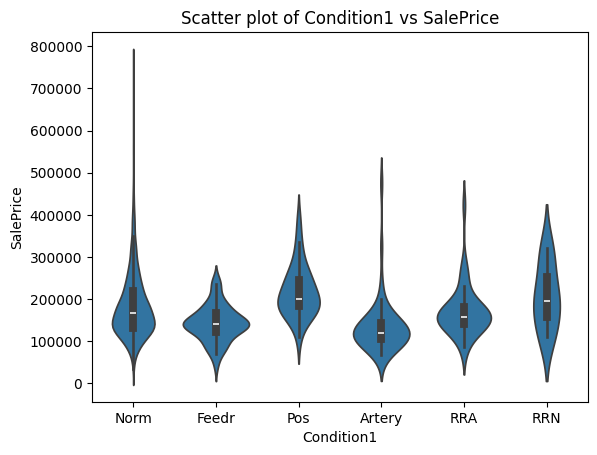

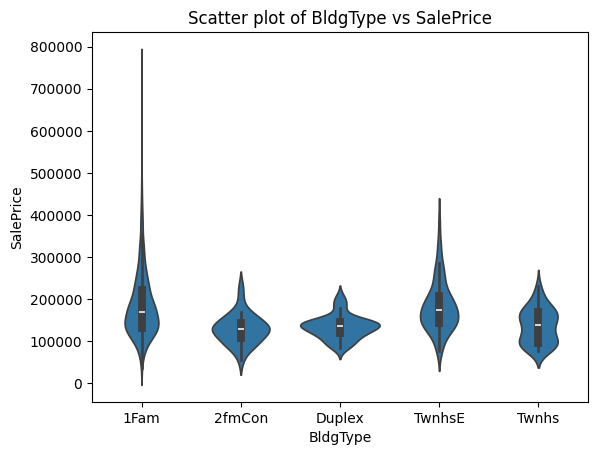

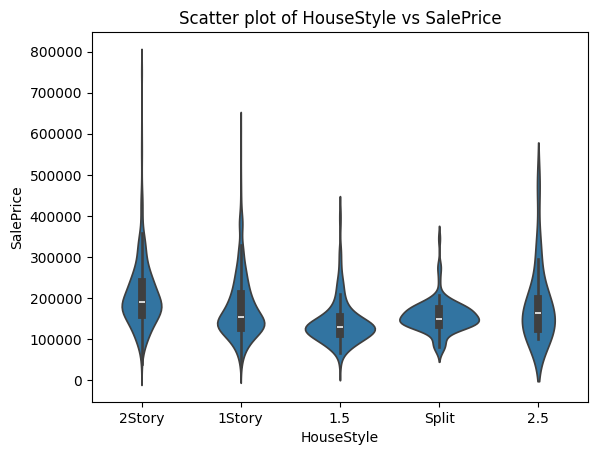

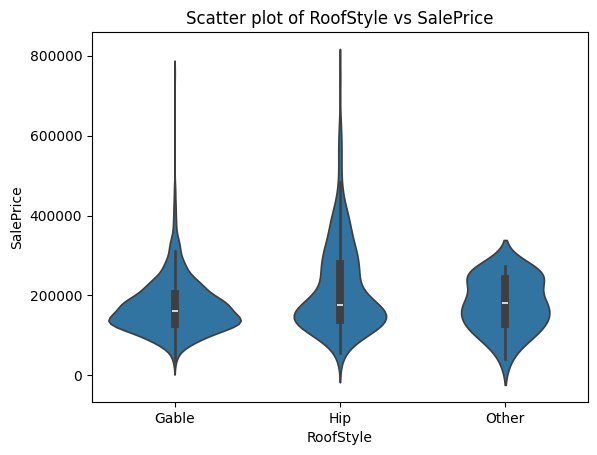

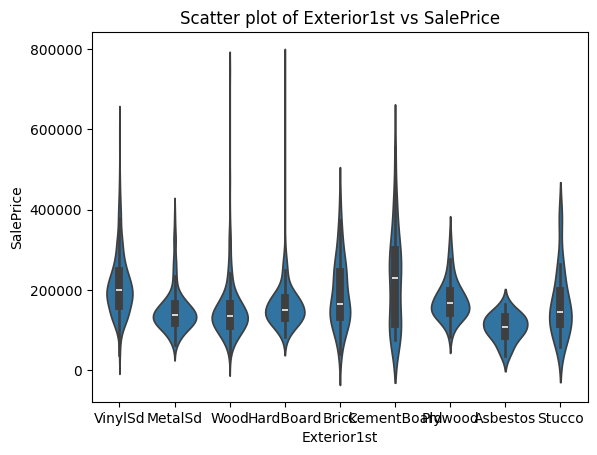

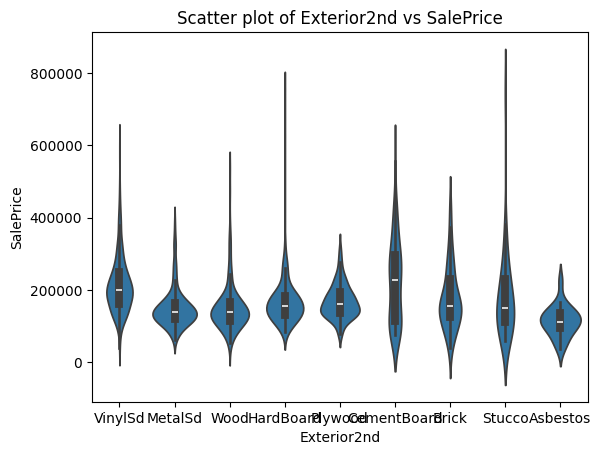

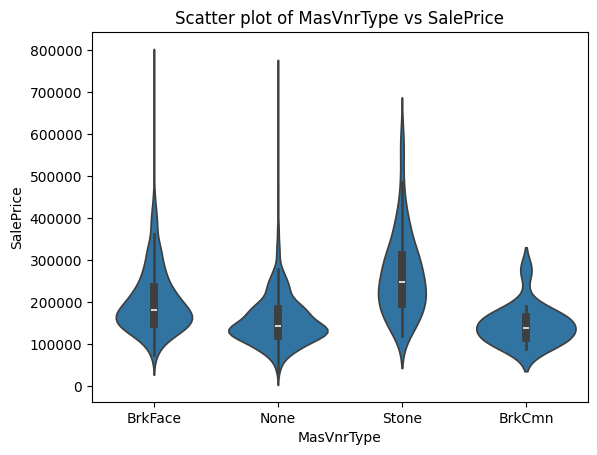

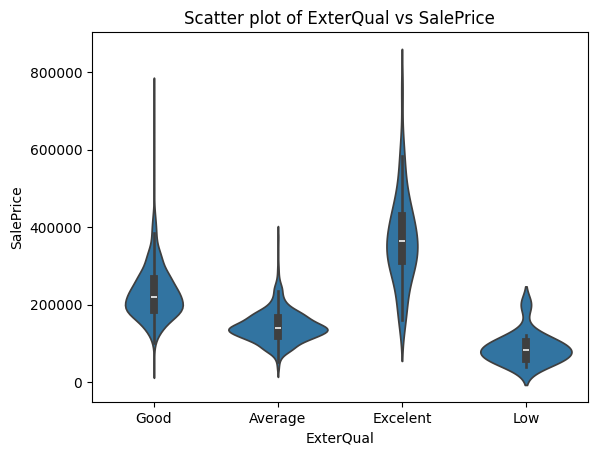

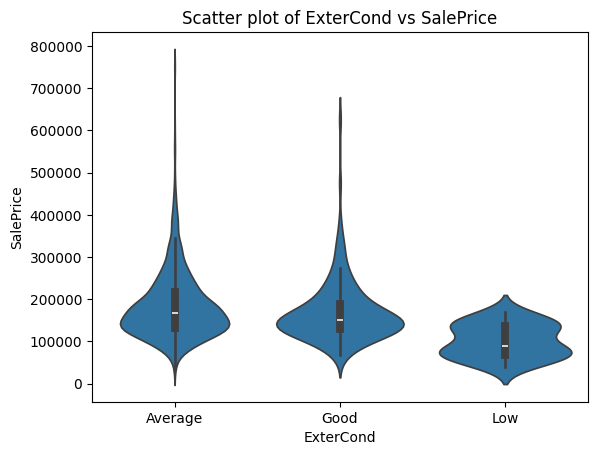

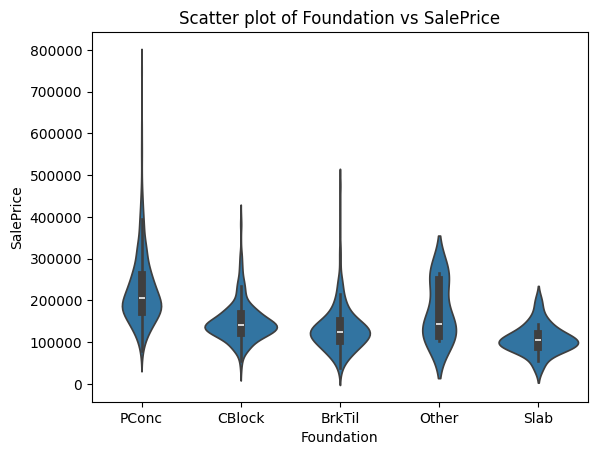

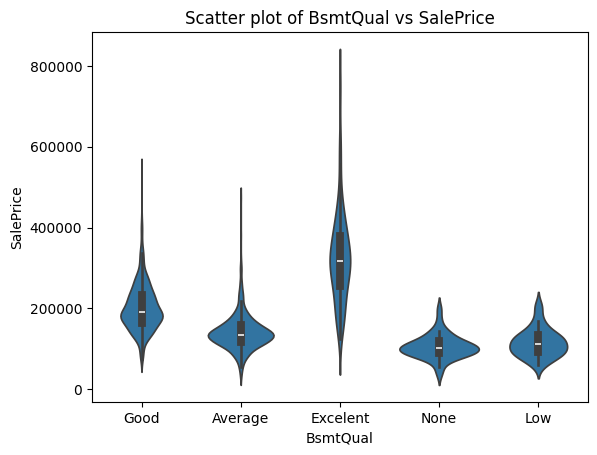

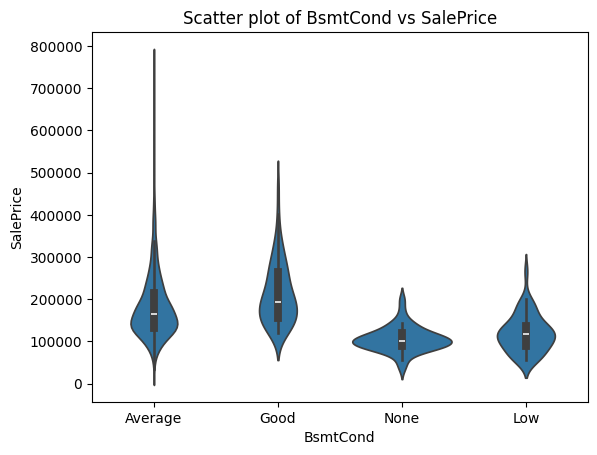

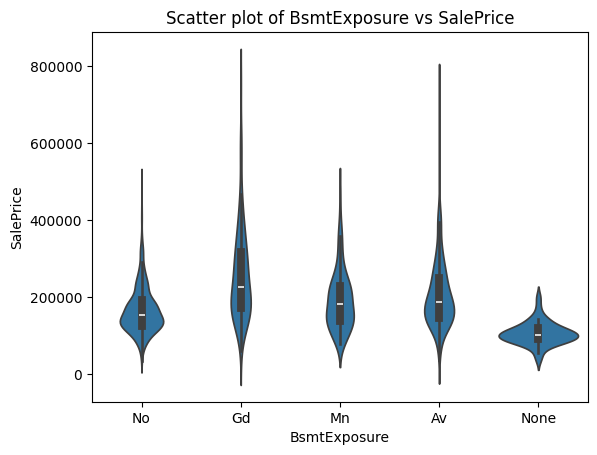

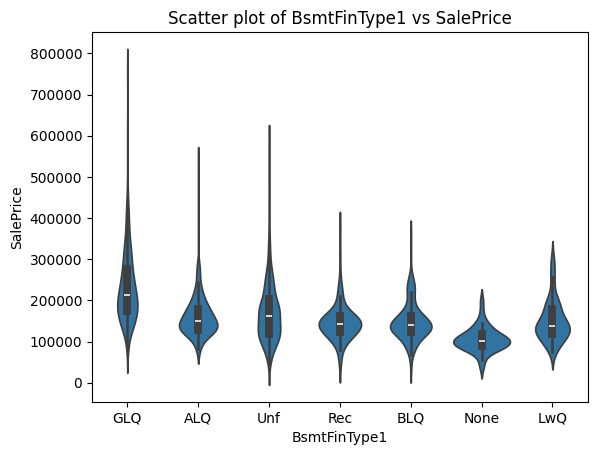

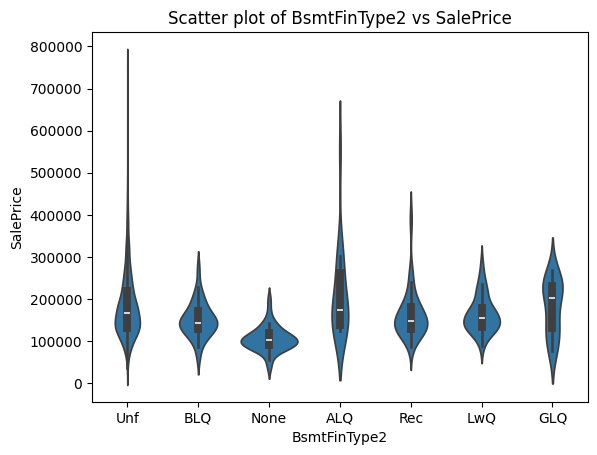

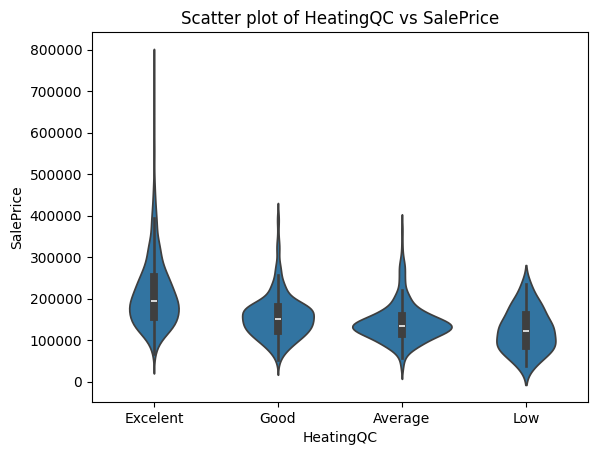

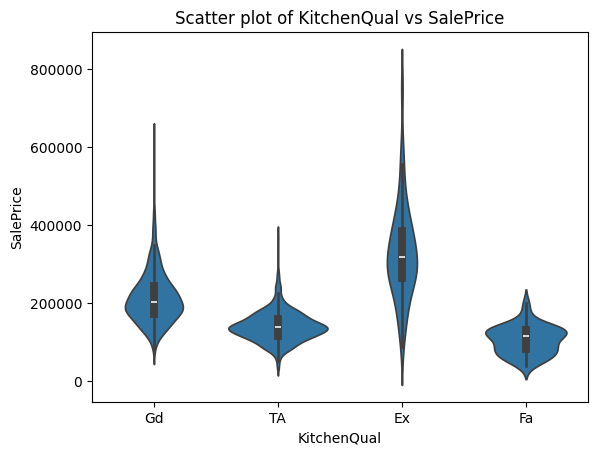

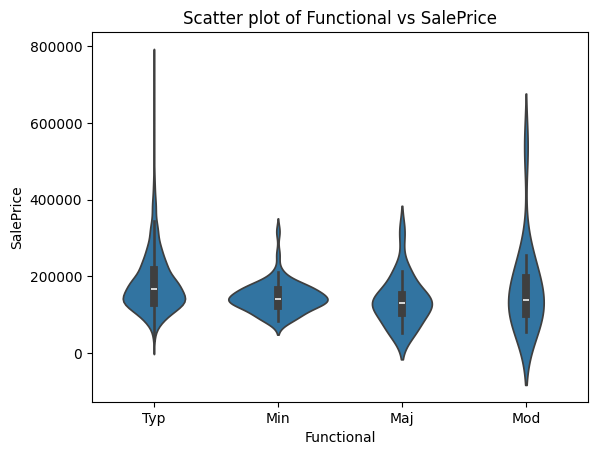

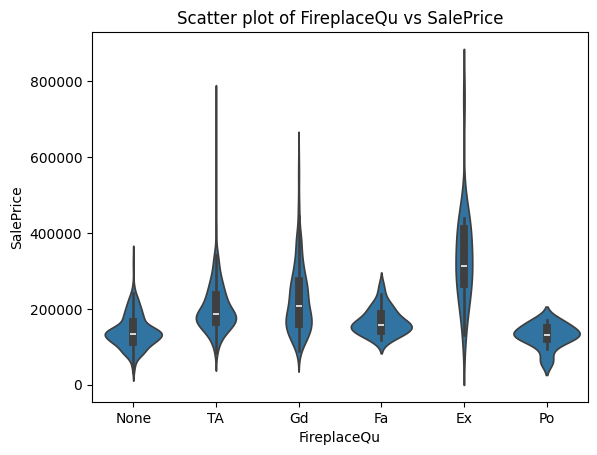

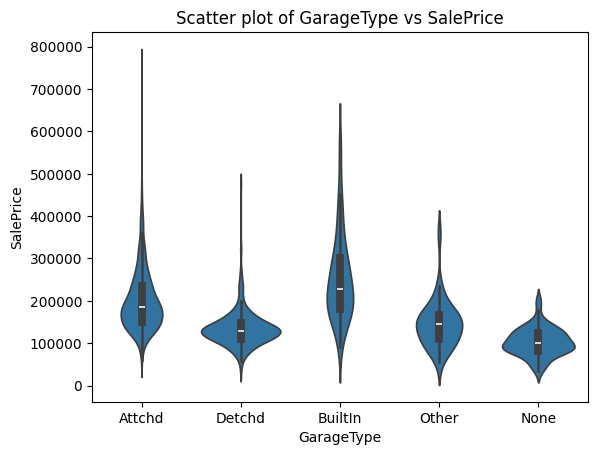

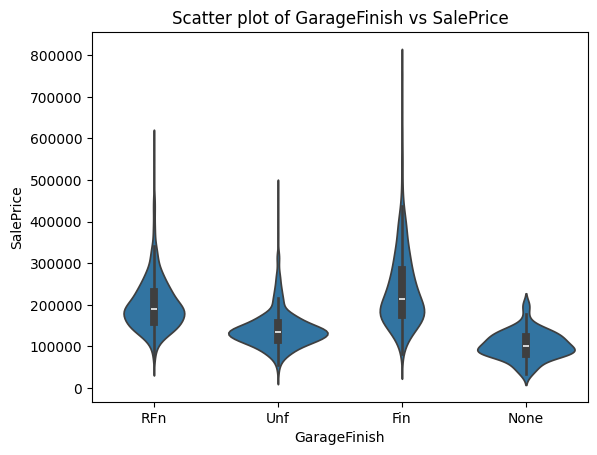

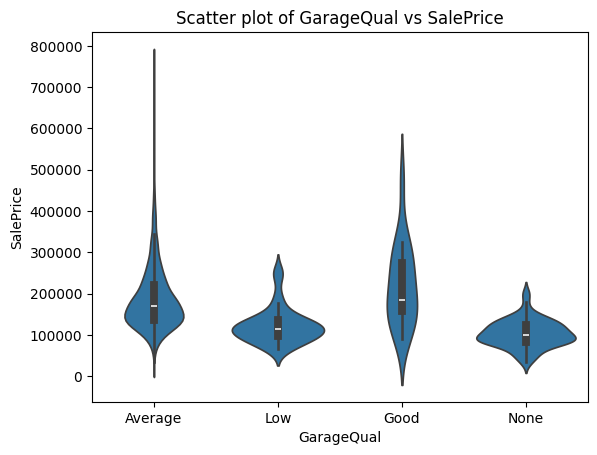

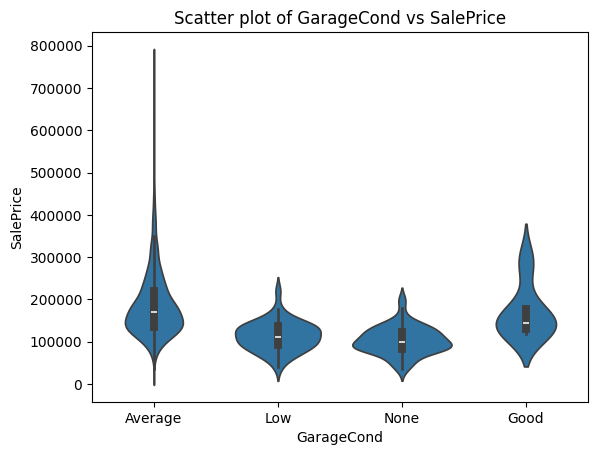

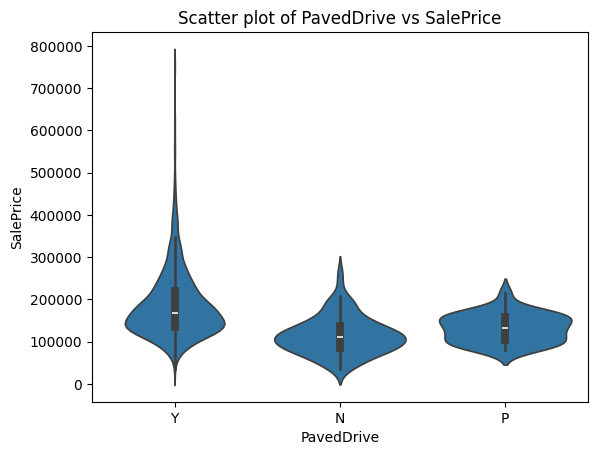

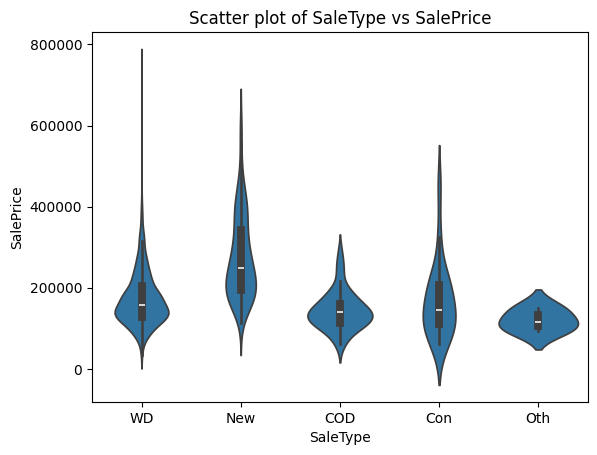

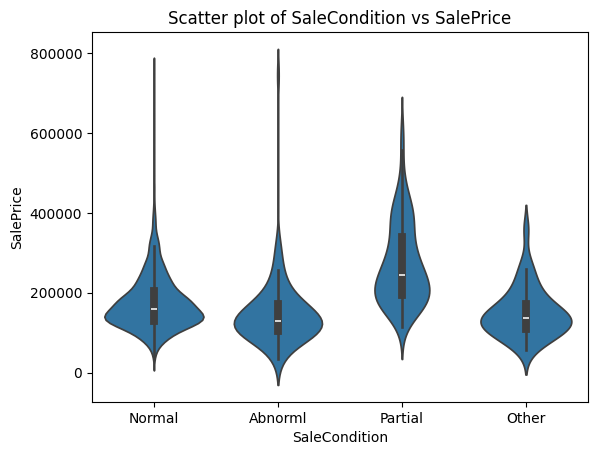

In [ ]:
#VIOLINPLOT
for col in df.columns:
    if df[col].dtype == 'O' and len(df[col].unique()) != 2:
      sns.violinplot(x=col, y='SalePrice', data=df)
      plt.title(f'Scatter plot of {col} vs SalePrice')
      plt.show()

#**5 | DATASET SPLITS**

Once the **data cleaning** has been completed and the columns checked during the **univariate analysis**, the next step will be to proceed with splitting the DataFrame.

This step must be done before the actual preprocessing, in order to avoid potential data leakage that could negatively affect the true predictive ability of the model.

* **CREATE A COPY**

In [ ]:
df2 = df.copy()
df2_file_route = ''
df2.to_csv(df2_file_route, index=False)

##**5.1 | SPLIT: X-y**

###**5.1.1 | SPLIT PROCESS**

The first step when building an ML model is to define the target (**dependent variable - y**) to be predicted.

* **DEFINE target - y**

In [ ]:
target = 'SalePrice'

* **DEFINE features - X**

The next step will be to generate a list of **independent variables - X**, excluding the target.

In [ ]:
features = []
for col in df2.columns:
  if col != target:
    features.append(col)

* **SPLIT X-y**

In [ ]:
y = df2[target]
X = df2[features]

###**5.1.2 | target DISTRIBUTION**

Once the target and features are separated, an analysis of the **target** and its distribution can begin, in order to ensure there are no significant imbalances between **True / False** values that could affect the model’s performance.

* **ABSOLUTE VALUES**

In [ ]:
y.mean()

np.float64(180921.19589041095)

* **VISUALIZATION**

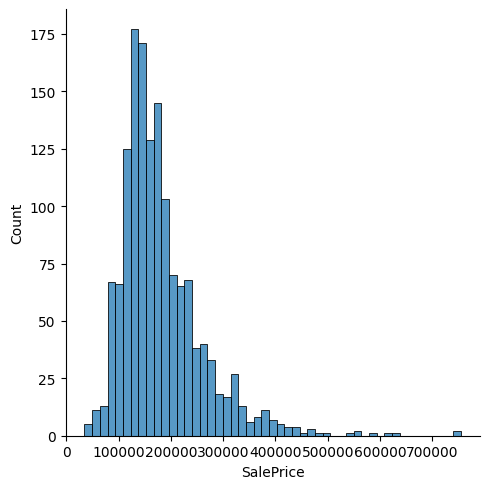

In [ ]:
sns.displot(x=y)

Once the **data cleaning** has been completed and the columns checked during the **univariate analysis**, the data **pre-processing** tasks can proceed, with the ultimate goal of creating a data table that can be read and interpreted by an ML model.


##**5.2 | SPLIT: TRAIN-TEST**

With the **target variable 'y'** and **features 'X'** defined, separated, and the target analyzed, the next step will be to split the data into **TRAIN** and **TEST** sets.

To perform the split, you can use either the **HOLDOUT** method or the **RANDOM HOLDOUT** method.

* **TRAIN - TEST SPLIT**

Using the `sklearn.model_selection` library, the function `train_test_split()` will be selected. Four new variables should be created to store the train and test values of both 'y' and 'X'.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                                   X,
                                   y,
                                   test_size = 0.30,
                                   shuffle = False
                                  #stratify=y
                                    )

The parameter **stratify=y** forces the True/False proportion to be maintained between the TRAIN data and the TARGET. In this case, it will not be used, as maintaining the strict temporality of the values will be prioritized.

##**5.2 SPLIT VISUALIZATION**

* **LENGHT**

In [ ]:
print('TRAIN REGISTERS:', len(y_train))
print('TEST REGISTERS:', len(y_test))

TRAIN REGISTERS: 1022
TEST REGISTERS: 438


* **DENSITY**

As can be seen, despite not forcing the values to maintain the proportion, they show a very similar distribution between the **TRAIN** and **TEST** sets.

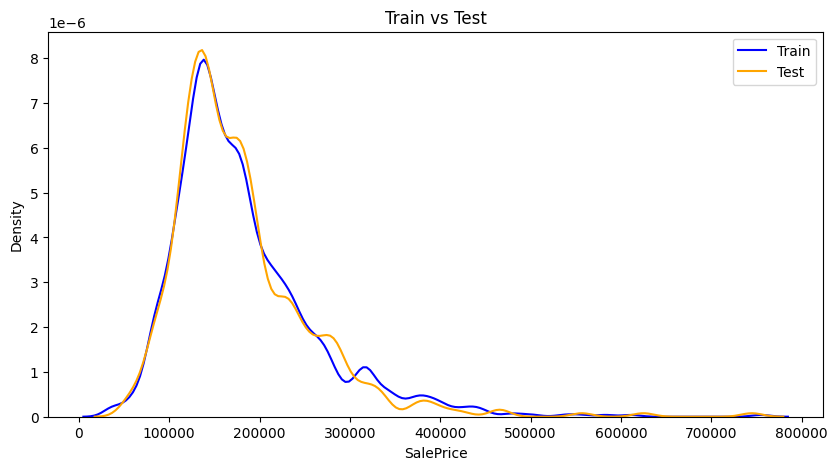

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_train, color="blue", label="Train", bw_adjust=0.5)
sns.kdeplot(y_test, color="orange", label="Test", bw_adjust=0.5)
plt.title("Train vs Test")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.legend()
plt.show()

* **STADISTICS**

By analyzing the main comparative values, it can be observed that there are also no significant differences between the statistical values of `y_train` and `y_test`.

In [ ]:
stats = ['mean', 'median', 'std', 'min', '25%', '75%', 'max']

data = {
    'y_test': [
        y_test.mean(),
        y_test.median(),
        y_test.std(),
        y_test.min(),
        y_test.quantile(0.25),
        y_test.quantile(0.75),
        y_test.max()
    ],
    'y_train': [
        y_train.mean(),
        y_train.median(),
        y_train.std(),
        y_train.min(),
        y_train.quantile(0.25),
        y_train.quantile(0.75),
        y_train.max()
    ]}

df_stats = pd.DataFrame(data, index=stats).round(2)
df_stats

,y_test,y_train
mean,179073.06,181713.25
median,161750.00,163745.00
std,78531.94,79854.66
min,52500.00,34900.00
25%,129125.00,130000.00
75%,208425.00,214975.00
max,745000.00,755000.00


#**6 | ML: PREPROCESSING**

##**6.1 | CATEGORICAL VARIABLE ENCODING**

The first step in preprocessing will be to convert the set of categorical variables in **`X_train`** and **`X_test`** into numerical values. This can be done using **One Hot Encoder** or **Ordinal Encoder** techniques.


In [ ]:
cat_col = list(X_train.select_dtypes(include='object').columns)
print(cat_col)

['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition']


In [ ]:
for i in X_train:
  if X_train[i].dtype.kind == 'O':
    print(i, X_train[i].value_counts(), '\n')

MSZoning MSZoning
RL         801
RM         152
FV          50
RH          11
C (all)      8
Name: count, dtype: int64 

LotShape LotShape
Reg      639
IR1      346
IR2_3     37
Name: count, dtype: int64 

LandContour LandContour
Lvl    921
Bnk     39
HLS     36
Low     26
Name: count, dtype: int64 

LotConfig LotConfig
Inside     732
Corner     189
CulDSac     67
FR2_3       34
Name: count, dtype: int64 

LandSlope LandSlope
Gtl    967
Mod     44
Sev     11
Name: count, dtype: int64 

Neighborhood Neighborhood
D    267
C    261
E    189
B    149
A    106
F     50
Name: count, dtype: int64 

Condition1 Condition1
Norm      880
Feedr      55
Artery     34
RRA        26
Pos        21
RRN         6
Name: count, dtype: int64 

BldgType BldgType
1Fam      853
TwnhsE     79
Duplex     38
Twnhs      29
2fmCon     23
Name: count, dtype: int64 

HouseStyle HouseStyle
1Story    512
2Story    315
1.5       113
Split      68
2.5        14
Name: count, dtype: int64 

RoofStyle RoofStyle
Gable    80

###**6.1.1 | ORDINAL ENCODER**

In [ ]:
oe_columns = ['PavedDrive','GarageCond','GarageQual','HeatingQC',
              'BsmtExposure','BsmtCond','BsmtQual','ExterCond',
              'ExterQual','Neighborhood','FireplaceQu','KitchenQual',
              'Functional','GarageFinish','LotShape','LandSlope']

oe_values = [
    ['N','P','Y'],
    ['None','Low','Average','Good'],
    ['None','Low','Average','Good'],
    ['Low','Average','Good','Excelent'],
    ['None', 'No', 'Mn', 'Av', 'Gd'],
    ['None', 'Low', 'Average', 'Good'],
    ['None', 'Low', 'Average', 'Good', 'Excelent'],
    ['Low', 'Average', 'Good'],
    ['Low', 'Average', 'Good', 'Excelent'],
    ['F', 'E', 'D', 'C', 'B', 'A'],
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Fa', 'TA', 'Gd', 'Ex'],
    ['Maj', 'Mod', 'Min', 'Typ'],
    ['None', 'Unf', 'RFn', 'Fin'],
    ['Reg','IR1','IR2_3'],
    ['Sev', 'Mod', 'Gtl'],
    ]

In [ ]:
encoder = OrdinalEncoder(categories = oe_values,
                         handle_unknown = 'use_encoded_value',
                         unknown_value = -1)

X_train[oe_columns] = encoder.fit_transform(X_train[oe_columns])
X_test[oe_columns] = encoder.transform(X_test[oe_columns])

###**6.1.2 | ONE HOT ENCODER**

In [ ]:
ohe_columns = list(X_train.select_dtypes(include='object').columns)

In [ ]:
X_train = pd.get_dummies(X_train, columns=ohe_columns)
X_test = pd.get_dummies(X_test, columns=ohe_columns)

##**6.2 | FEATURE SELECTION**

###**6.2.1 | MATRIX CORRELATION - INDEPENDENT VARIABLES**

In [ ]:
n_corr = X_train.corr(numeric_only=True)
n_corr.style.background_gradient(cmap='coolwarm')

Output hidden; open in https://colab.research.google.com to view.

###**6.2.2 | MATRIX CORRELATION - DEPENDENT VARIABLE**

In [ ]:
df_train = X_train.copy()
df_train['target'] = y_train

#column order
cols = ['target'] + [col for col in df_train.columns if col != 'target']
df_train = df_train[cols]

In [ ]:
n_corr_train = df_train.corr(numeric_only=True)
n_corr_train.style.background_gradient(cmap='coolwarm')

Output hidden; open in https://colab.research.google.com to view.

###**6.2.3 | HIGH INDEPENDENT VARIABLE CORRELATION**

In [ ]:
def highly_correlated(X, y, threshold=0.95):
    col_corr = []  # List of variables candidates to be eliminated
    colnames = []
    rownames = []
    corr_matrix = df_train.corr().abs()


    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            if corr_matrix.iloc[i, j] >= threshold and var2 not in col_corr:
                colnames.append(var1)
                rownames.append(var2)
                col_corr.append(corr_matrix.iloc[i, j])

    # Dataframe with the correlation information
    Z = pd.DataFrame({
        'F1': colnames,
        'F2': rownames,
        'corr_F1_F2': col_corr,
        'corr_F1_target': [np.abs(np.corrcoef(X[f1], y)[0, 1]) for f1 in colnames],
        'corr_F2_target': [np.abs(np.corrcoef(X[f2], y)[0, 1]) for f2 in rownames]
    })

    Z['F_to_delete'] = Z['F2']
    Z.loc[Z['corr_F1_target'] < Z['corr_F2_target'], 'F_to_delete'] = Z['F1']

    return Z

In [ ]:
highly_corr = highly_correlated(X_train,y_train,0.95)
highly_corr

,F1,F2,corr_F1_F2,corr_F1_target,corr_F2_target,F_to_delete
0,PoolQC,PoolArea,1.000000,0.014584,0.014584,PoolArea
1,MiscVal,MiscFeature,0.987799,0.095648,0.097552,MiscVal
2,Exterior2nd_CementBoard,Exterior1st_CementBoard,0.953508,0.123898,0.147321,Exterior2nd_CementBoard
3,Exterior2nd_MetalSd,Exterior1st_MetalSd,0.980372,0.164471,0.170655,Exterior2nd_MetalSd
4,Exterior2nd_VinylSd,Exterior1st_VinylSd,0.980747,0.330467,0.330043,Exterior1st_VinylSd
5,BsmtFinType2_None,BsmtFinType1_None,1.000000,0.146494,0.146494,BsmtFinType1_None
6,GarageType_None,GarageYrBlt,0.999962,0.243209,0.247367,GarageType_None
7,SaleCondition_Partial,SaleType_New,0.988009,0.372461,0.380733,SaleCondition_Partial


In [ ]:
list(highly_corr['F_to_delete'])
drop_cols = list(highly_corr['F_to_delete'])

* **DROPS**

In [ ]:
X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

###**6.2.4 | LOW VARIANCE**

In [ ]:
X_train_columns = set(X_train.columns)

# 1. Filter variables with low correlation with the target variable (|corr| < 0.01)
corr_with_target = X_train.apply(lambda col: np.abs(np.corrcoef(col, y_train)[0,1]))
low_corr_vars = corr_with_target[corr_with_target < 0.05].index.tolist()

# 2. Apply VarianceThreshold only with variables with low correlation
selector = VarianceThreshold(threshold=0.005)
X_train_low_corr = X_train[low_corr_vars]

X_train_thresh = selector.fit_transform(X_train_low_corr)
X_test_thresh = selector.transform(X_test[low_corr_vars])

selected_low_corr_features = X_train_low_corr.columns[selector.get_support()]

# 3. Variables with low correlation & high variance - FILTER PASSED
vars_to_keep_low_corr = set(selected_low_corr_features)

# 4. Variables that do NO pass the filters: low correlation & low variance (to drop)
vars_to_remove = set(low_corr_vars) - vars_to_keep_low_corr

# 5. Drop the variables from both datasets
X_train_filtered = X_train.drop(columns=vars_to_remove)
X_test_filtered = X_test.drop(columns=vars_to_remove)

# Mostrar variables eliminadas
print('Dropped variables (high correlation & low variance)')
print(vars_to_remove)


Variables eliminadas (baja correlación y baja varianza):
{'StreetPaved', 'PoolQC', 'Foundation_Other', 'SaleType_Oth'}


##**6.3 | RESCALING**

In [ ]:
#SCALER IMPORT
scaler = StandardScaler()

#FIT & TRANSFORM
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#GENERATING STANDARIZED DATASETS
X_train_std = pd.DataFrame(X_train_std, columns = X_train.columns, index= X_train.index)
X_test_std = pd.DataFrame(X_test_std, columns = X_test.columns, index= X_test.index)

##**6.4 | MODEL COMPETITION**

This will be done using **K-Fold validation**, which provides an average prediction from k models trained on different test partitions, making it a good method for small datasets (fewer than 10,000 samples).


###**6.4.1 | MODEL COMPETITION PREPARATION**

* **FUNCTIONS**

In [ ]:
def RMSE(model,X,y):
  model.fit(X,y)
  return round(np.sqrt(np.mean((y-model.predict(X))**2)),2)

def RMSE_cross_validation(model,X,y):
  Kfold_rmse = cross_val_score(model, X, y, cv=4, scoring='neg_root_mean_squared_error')
  return round(-Kfold_rmse.mean(),4)

In [ ]:
# Inicializa resultados
label_ = []
rmse_train_ = []
rmse_valida_ = []

# Funcion que devuelve un dataframe con resultados de RMSE Cross Validation
def evaluate_regression(model, X, y, label=None):
  if label is None:
    label = str(model)

  rmse_train = RMSE(model,X,y)
  rmse_valida = RMSE_cross_validation(model,X,y)

  label_.append(label)
  rmse_train_.append(rmse_train)
  rmse_valida_.append(rmse_valida)

  return pd.DataFrame({'Model': label_,
                      'RMSE Train': rmse_train_,
                      'RMSE Cross-Validation': rmse_valida_
                      }).sort_values('RMSE Cross-Validation')

###**6.4.2 | MODEL COMPETITION**

In [ ]:
evaluate_regression(model = LinearRegression(),
                    X=X_train_std, y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
0,LinearRegression(),25278.89,30312.3093


In [ ]:
evaluate_regression(model = Lasso(alpha=1),
                    X=X_train_std, y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603


In [ ]:
evaluate_regression(model = Ridge(alpha=10),
                    X=X_train_std, y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603


In [ ]:
evaluate_regression(model = ElasticNet(l1_ratio=0.5),
                    X=X_train_std, y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603


In [ ]:
poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train_std)

evaluate_regression(label='Polynomial 2D',
                    model = LinearRegression(),
                    X=X_train_poly, y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
4,Polynomial 2D,0.00,39663.8416


In [ ]:
evaluate_regression(model = SGDRegressor(n_iter_no_change=1000,
                                         penalty=None,
                                         eta0=0.01,
                                         max_iter=10000),
                    X=X_train_std,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
4,Polynomial 2D,0.00,39663.8416


In [ ]:
evaluate_regression(model = GaussianProcessRegressor(),
                    X=X_train,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
4,Polynomial 2D,0.00,39663.8416
6,GaussianProcessRegressor(),0.00,198405.8607


In [ ]:
evaluate_regression(model = KNeighborsRegressor(n_neighbors = 3),
                    X=X_train_std,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
4,Polynomial 2D,0.00,39663.8416
7,KNeighborsRegressor(n_neighbors=3),26910.20,40435.3308
6,GaussianProcessRegressor(),0.00,198405.8607


In [ ]:
evaluate_regression(model = KNeighborsRegressor(n_neighbors = 6),
                    X=X_train_std,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
8,KNeighborsRegressor(n_neighbors=6),32896.11,39659.9745
4,Polynomial 2D,0.00,39663.8416
7,KNeighborsRegressor(n_neighbors=3),26910.20,40435.3308
6,GaussianProcessRegressor(),0.00,198405.8607


In [ ]:
evaluate_regression(model = RandomForestRegressor(n_estimators=100,
                                                  max_depth=3),
                    X=X_train,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
9,RandomForestRegressor(max_depth=3),32699.64,37044.9671
8,KNeighborsRegressor(n_neighbors=6),32896.11,39659.9745
4,Polynomial 2D,0.00,39663.8416
7,KNeighborsRegressor(n_neighbors=3),26910.20,40435.3308
6,GaussianProcessRegressor(),0.00,198405.8607


In [ ]:
evaluate_regression(model = XGBRegressor(objective ='reg:squarederror'),
                    X=X_train,
                    y=y_train)

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
10,"XGBRegressor(base_score=None, booster=None, ca...",866.50,30407.2988
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
9,RandomForestRegressor(max_depth=3),32699.64,37044.9671
8,KNeighborsRegressor(n_neighbors=6),32896.11,39659.9745
4,Polynomial 2D,0.00,39663.8416
7,KNeighborsRegressor(n_neighbors=3),26910.20,40435.3308


###**6.4.3 | MODEL COMPETITION - RESULT**

In [ ]:
pd.DataFrame({'Model': label_,
                      'RMSE Train': rmse_train_,
                      'RMSE Cross-Validation': rmse_valida_
                      }).sort_values('RMSE Cross-Validation')

,Model,RMSE Train,RMSE Cross-Validation
3,ElasticNet(),27543.45,29193.9735
2,Ridge(alpha=10),25403.06,29609.7738
0,LinearRegression(),25278.89,30312.3093
1,Lasso(alpha=1),25331.98,30334.4603
10,"XGBRegressor(base_score=None, booster=None, ca...",866.50,30407.2988
5,"SGDRegressor(max_iter=10000, n_iter_no_change=...",25368.73,30878.3739
9,RandomForestRegressor(max_depth=3),32699.64,37044.9671
8,KNeighborsRegressor(n_neighbors=6),32896.11,39659.9745
4,Polynomial 2D,0.00,39663.8416
7,KNeighborsRegressor(n_neighbors=3),26910.20,40435.3308


##**6.5 | MODEL SELECTION & HYPERPARAMETRES**

Based on the results obtained in the competition, the model with the **best performance on the TEST data** will be selected. The best result is understood as the one that, on average, deviates the least from the actual prices. In this case, the lowest RMSE was achieved by **ElasticNet()**.


```
                TRAIN   TEST
ElasticNet()	27543.45	29193.9735
```

* **SEARCH AVAILABLE PARAMETRES**

In [ ]:
ElasticNet?

In [ ]:
print(ElasticNet().get_params())

{'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'l1_ratio': 0.5, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}


* **HYPERPARAMETRES**

In [ ]:
parameters_hp = {'alpha': [0.001, 0.01, 0.1, 0.5,0.75],
                 'copy_X': [True, False],
                 'fit_intercept': [True, False],
                 'l1_ratio': [0.10, 0.25, 0.5, 0.75,0.90],
                 'max_iter': [1000,2000,3000],
                 'positive': [True, False],
                 'precompute': [True, False],
                 #'random_state': None,
                 'selection': ['cyclic', 'random'],
                 'tol': [1e-4, 1e-3, 1e-2],
                 'warm_start': [True, False]
                 }

In [ ]:
#Configuration tests based on RandomizedSearchCV
search_hp = RandomizedSearchCV(estimator=ElasticNet(),
                               param_distributions = parameters_hp,
                               scoring='neg_root_mean_squared_error',     # metrics to optimizer: RMSE
                               cv = 4,                                    # fold numbers for the cross-validation
                               n_iter = 50,                               # number of iterations, each one with different configuration
                               n_jobs=-1,
                               verbose=True)

#**7 | MODEL FITTING & TRANSFORM**

##**7.1 | APPLY HYPERPARAMETRES & FIT_TRANSFORM TRAIN DATA**

The first step will be to fit the train data with the best hyperparametrer estimation that was get it from the search.

In [ ]:
search_hp.fit(X_train_std, y_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


RandomizedSearchCV(cv=4, estimator=ElasticNet(), n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 0.5, 0.75],
                                        'copy_X': [True, False],
                                        'fit_intercept': [True, False],
                                        'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                                        'max_iter': [1000, 2000, 3000],
                                        'positive': [True, False],
                                        'precompute': [True, False],
                                        'selection': ['cyclic', 'random'],
                                        'tol': [0.0001, 0.001, 0.01],
                                        'warm_start': [True, False]},
                   scoring='neg_root_mean_squared_error', verbose=True)

* **OUTPUT**

In [ ]:
print("---- Results from Random Search -----" )
print("\n The best estimator across ALL searched params:", search_hp.best_estimator_)
print("\n The best RMSE:", round(-search_hp.best_score_,3))
print("\n The best parameters across ALL searched params:\n", search_hp.best_params_)

---- Results from Random Search -----

 The best estimator across ALL searched params: ElasticNet(alpha=0.5, copy_X=False, precompute=True, tol=0.001, warm_start=True)

 The best RMSE: 28750.184

 The best parameters across ALL searched params:
 {'warm_start': True, 'tol': 0.001, 'selection': 'cyclic', 'precompute': True, 'positive': False, 'max_iter': 1000, 'l1_ratio': 0.5, 'fit_intercept': True, 'copy_X': False, 'alpha': 0.5}


* **FINAL MODEL**

In [ ]:
model = search_hp.best_estimator_

##**7.2 | APPLY TRANSFORM ON TEST DATA**

Once the model is fitted with the best hyperparametres, the next and final step will be to apply this configuration on the test data.

In [ ]:
y_train_pred = model.predict(X_train_std)              # model TRAIN predictions
y_test_pred = model.predict(X_test_std)                # model TEST predictions

##**7.3 | METRICS & RESULT INTERPRETATION**

###**7.3.1 | RMSE, MAE, MAPE & R2-SCORE**

* **STADISTICS**

In [ ]:
error = y_test_pred - y_test.values

mae = np.mean(np.abs(error))
mape = np.mean(error/y_test)
mse = np.mean(error**2)
rmse = np.sqrt(np.mean(error**2))

print('RMSE:', round(rmse,4))
print('MAE:', round(mae,4))
print('MAPE: {:.3%}'.format(mape))
print('R2-Score: {:.2%}'.format(r2_score(y_test, y_test_pred)))

RMSE: 39668.0076
MAE: 19499.1261
MAPE: 2.883%
R2-Score: 74.43%


* **ERROR DISTIBUTION GRAPHIC**

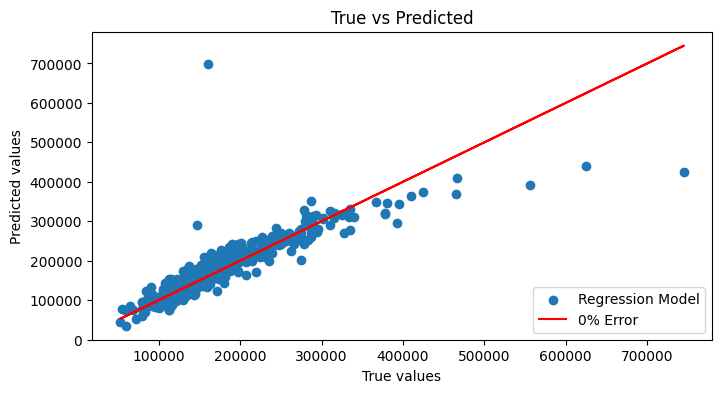

In [ ]:
plt.figure(figsize=[8,4])
plt.scatter(y_test,y_test_pred)
plt.plot(y_test,y_test,'r')
plt.title('True vs Predicted')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.legend(['Regression Model','0% Error'])
plt.show()

###**7.3.2 | ERROR DISTRIBUTION**

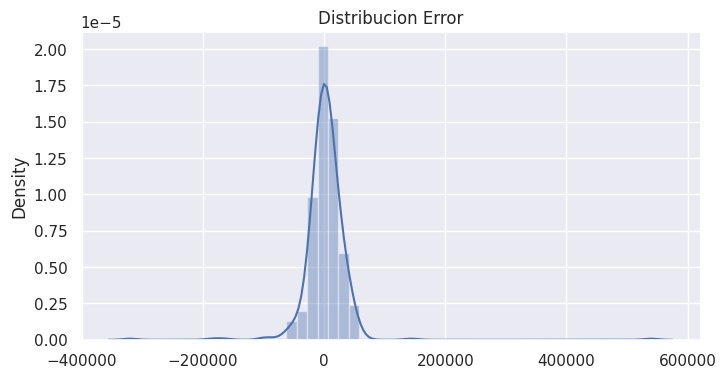

In [ ]:
sns.set(rc={'figure.figsize':(8,4)})
sns.distplot(error).set_title('Error Distribution')
plt.show()

In [ ]:
round(pd.Series(error).describe(),2)

,0
count,438.00
mean,2297.31
std,39646.71
min,-320550.18
25%,-10112.38
50%,2189.75
75%,15755.29
max,539509.63


* **CONFIDENCE INTERVAL**

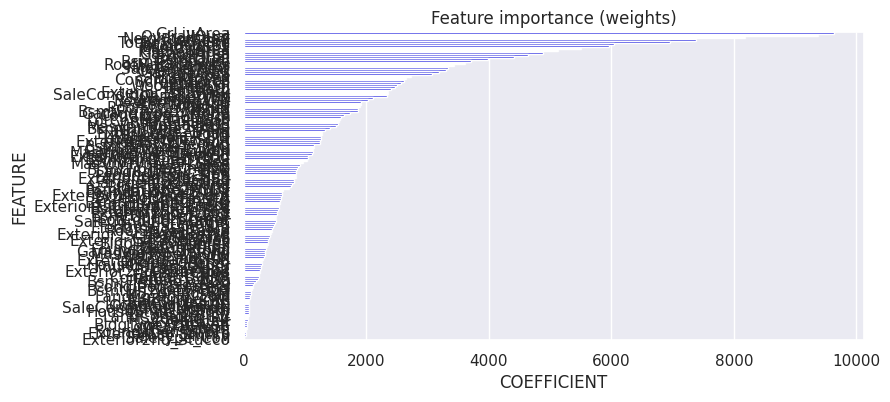

In [ ]:
df_coef = pd.DataFrame({'FEATURE':X_train.columns.values,
                        'COEFFICIENT': np.abs(model.coef_)}).sort_values('COEFFICIENT',ascending=False)
sns.barplot(data=df_coef,
            y='FEATURE',
            x='COEFFICIENT',
            color='blue')
plt.title('Feature importance (weights)')
plt.show()

In [ ]:
df_coef

,FEATURE,COEFFICIENT
26,GrLivArea,9638.757690
7,OverallQual,9377.531674
6,Neighborhood,8178.729493
23,1stFlrSF,7377.459689
34,TotRmsAbvGrd,6954.172078
...,...,...
109,Foundation_BrkTil,38.396931
96,Exterior1st_Stucco,37.620940
133,Fence_MnPrv,31.638184
136,SaleType_Con,1.975314


#**8 | PICKLE**

In [ ]:
picke_file_route = ''

In [ ]:
pickle.dump(model, open(picke_file_route, 'wb'))